In [25]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import allel 
import seaborn as sns
import allel
import os
import pickle

import dask.dataframe as dd

In [1]:
!pwd

/carnegie/nobackup/scratch/tbellagio/gea_grene-net/gwas/fitness_gwas


In [26]:
dict_snps = '/carnegie/nobackup/scratch/tbellagio/gea_grene-net/key_files/var_pos_grenenet.csv'
dict_snps = pd.read_csv(dict_snps)

In [27]:
dict_blocks = '/home/tbellagio/HapFM/blocks_snpsid_dict.pkl'

path = '/carnegie/nobackup/scratch/tbellagio/gea_grene-net/gwas/fitness_gwas'

In [28]:
with open(dict_blocks, 'rb') as file:
    dict_blocks = pickle.load(file)

In [29]:
dict_blocks_inv = {}

# Iterate through the original dictionary
for key, values in dict_blocks.items():
    for value in values:
        dict_blocks_inv[value] = key

In [30]:

def list_only_directories(path):
    # List all entries in the directory specified by path
    all_entries = os.listdir(path)
    all_entries = [i for i in os.listdir(path,) if 'site' in i]
    
    # Filter out the entries that are directories
    folder_names = [entry for entry in all_entries if os.path.isdir(os.path.join(path, entry))]
    
    return folder_names

# Usage example
sites = list_only_directories(path)

In [21]:
assoc = pd.read_csv(path + f'/{site}/output/{4}.assoc.txt', sep = '\t')

0.052

In [32]:
for site in sites:
    just_number_site = site.replace('site_', '')
    assoc = pd.read_csv(path + f'/{site}/output/{just_number_site}.assoc.txt', sep = '\t')
    th = 0.05 / len(assoc)
    # Add a new column 'significant' based on the condition
    assoc['significant'] = assoc['p_wald'] < th
    print(assoc['significant'].value_counts())
    assoc['blocks'] = assoc['rs'].map(dict_blocks_inv) 
    assoc = assoc.rename(columns = {'af': 'MAF'})
    assoc[['rs','p_wald', 'beta', 'significant', 'blocks','MAF']].to_csv(path + f'/{site}/output/results_lmm.csv', index=None)

significant
False    1147871
True          21
Name: count, dtype: int64
significant
False    1147834
True          58
Name: count, dtype: int64
significant
False    1147733
True         159
Name: count, dtype: int64
significant
False    1147885
True           7
Name: count, dtype: int64
significant
False    1147798
True          94
Name: count, dtype: int64
significant
False    1147869
True          23
Name: count, dtype: int64
significant
False    1147870
True          22
Name: count, dtype: int64
significant
False    1147885
True           7
Name: count, dtype: int64
significant
False    1147809
True          83
Name: count, dtype: int64
significant
False    1147726
True         166
Name: count, dtype: int64
significant
False    1147803
True          89
Name: count, dtype: int64
significant
False    1147883
True           9
Name: count, dtype: int64
significant
False    1147811
True          81
Name: count, dtype: int64
significant
False    1147817
True          75
Name: count, dtype

In [15]:
sites

['site_46',
 'site_55',
 'site_28',
 'site_10',
 'site_6',
 'site_1',
 'site_60',
 'site_25',
 'site_52',
 'site_32',
 'site_45',
 'site_5',
 'site_13',
 'site_2',
 'site_26',
 'site_42',
 'site_48',
 'site_37',
 'site_53',
 'site_24',
 'site_23',
 'site_54',
 'site_11',
 'site_49',
 'site_43',
 'site_9',
 'site_27',
 'site_57',
 'site_4',
 'site_12',
 'site_33']

In [4]:
site = 'site_4'

In [5]:
pvalues_file = path + f'/{site}/output/results_lmm.csv'

pvalues = dd.read_csv(pvalues_file)
pvalues = pvalues.compute()

pvalues.columns = ['id', 'pvalue','beta', 'significant', 'blocks']

threshold_value = 0.05 / len(pvalues)

In [10]:
pvalues.groupby('blocks')['significant'].sum()[pvalues.groupby('blocks')['significant'].sum() !=0]

blocks
1_1010    2
1_1041    1
1_1042    1
1_1079    1
1_1154    1
         ..
5_606     2
5_724     1
5_736     1
5_757     1
5_953     1
Name: significant, Length: 174, dtype: int64

In [16]:
pvalues_blocks = pvalues.groupby('blocks')['pvalue'].min().reset_index()

In [19]:
pvalues_blocks.sort_values('pvalue').head(10)

,blocks,pvalue
5464,2_1295,1.288339e-22
6147,2_1915,3.149070e-22
12716,4_2874,3.248814e-21
2066,1_2873,1.034414e-19
4768,1_663,3.384354e-19
50,1_1042,1.324229e-18
49,1_1041,1.324229e-18
12584,4_2754,2.483407e-18
12569,4_2740,2.483407e-18
12663,4_2826,4.079480e-18


In [6]:
pvalues['chromosome'] = pvalues['id'].str.split('_').str[0].astype(int)

In [15]:
sites = ['site_4', 'site_32']

/tmp/ipykernel_78550/1658760834.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


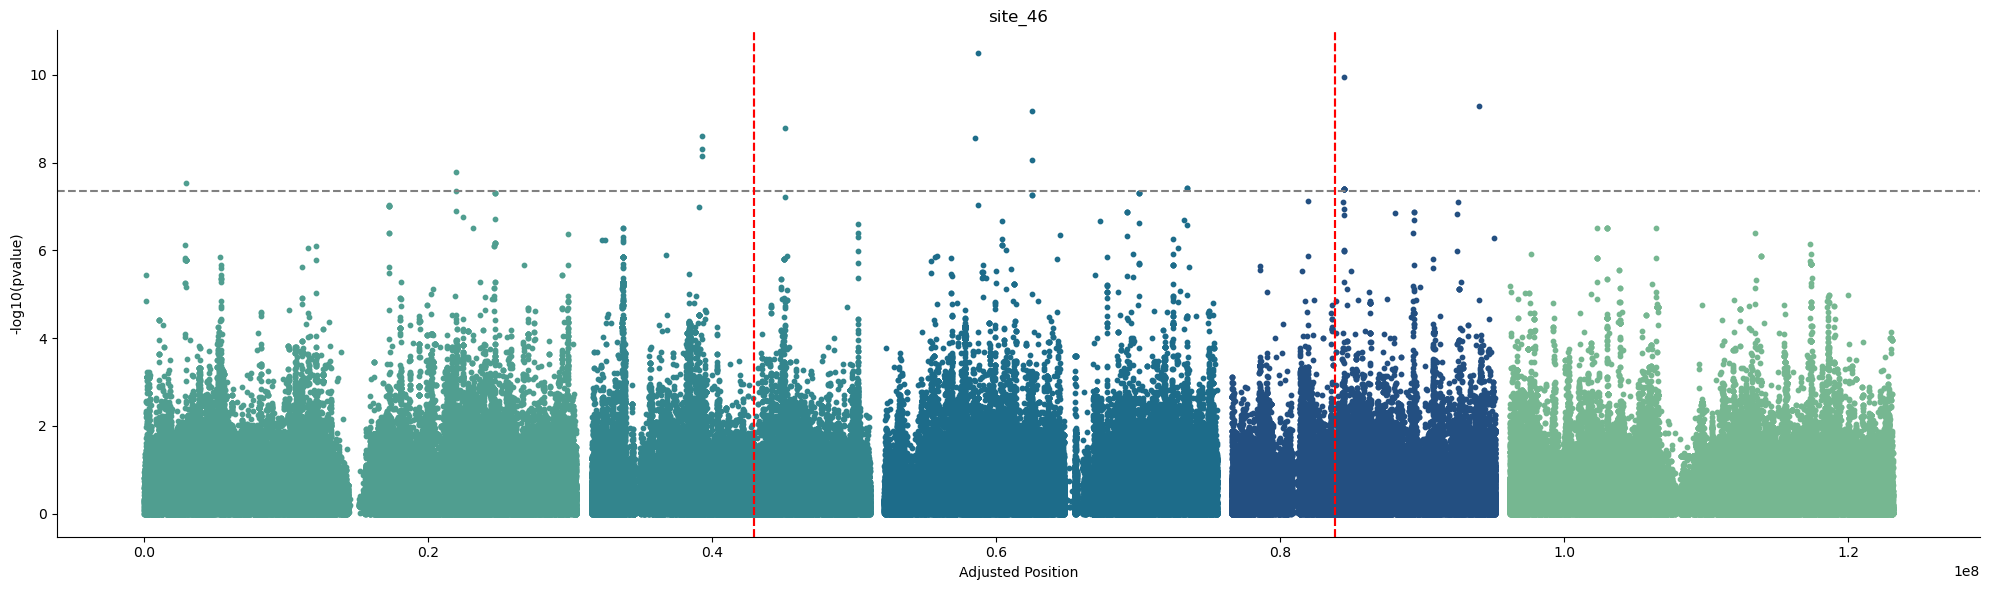

/tmp/ipykernel_78550/1658760834.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


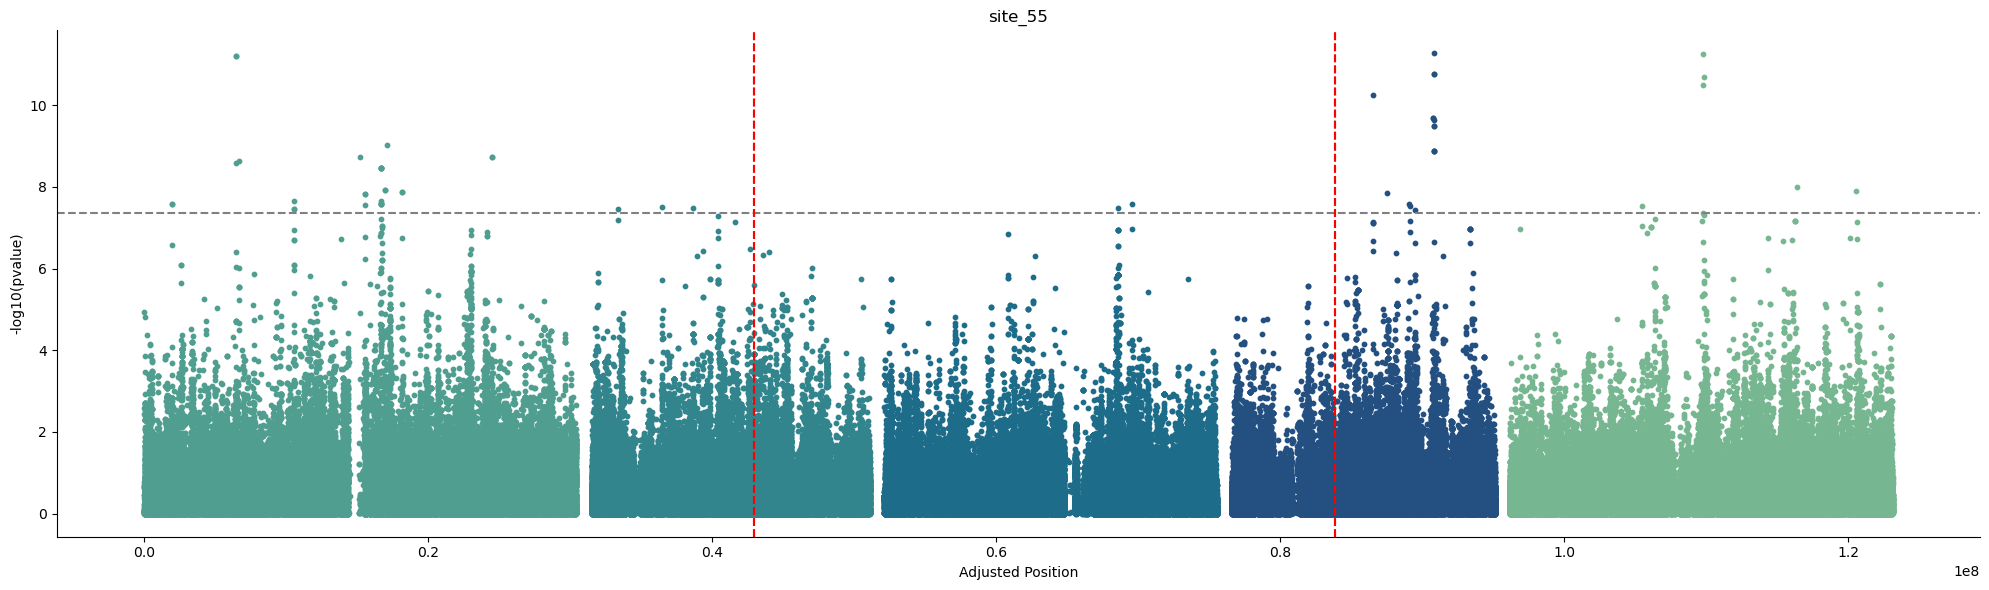

/tmp/ipykernel_78550/1658760834.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


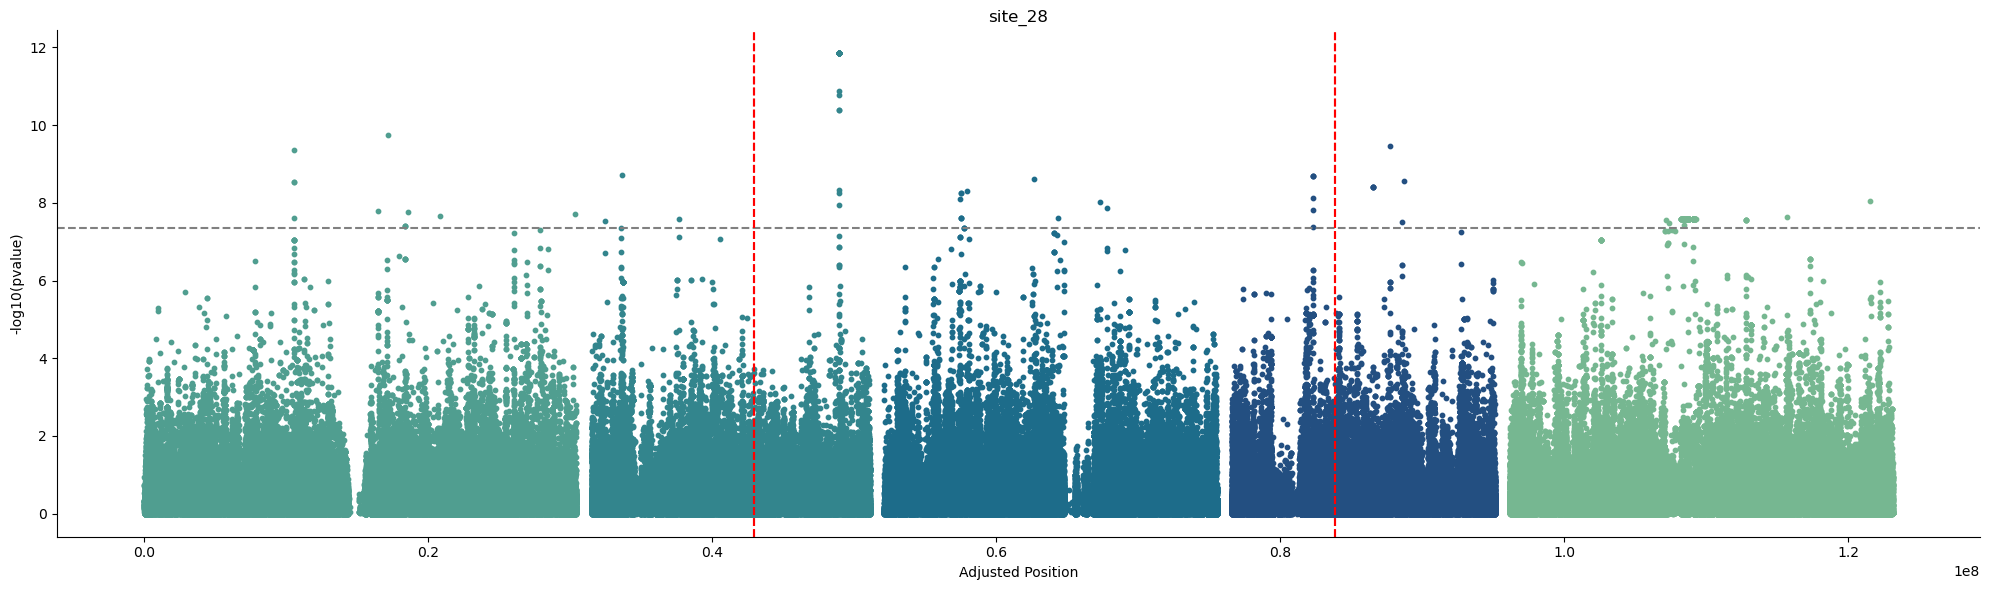

/tmp/ipykernel_78550/1658760834.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


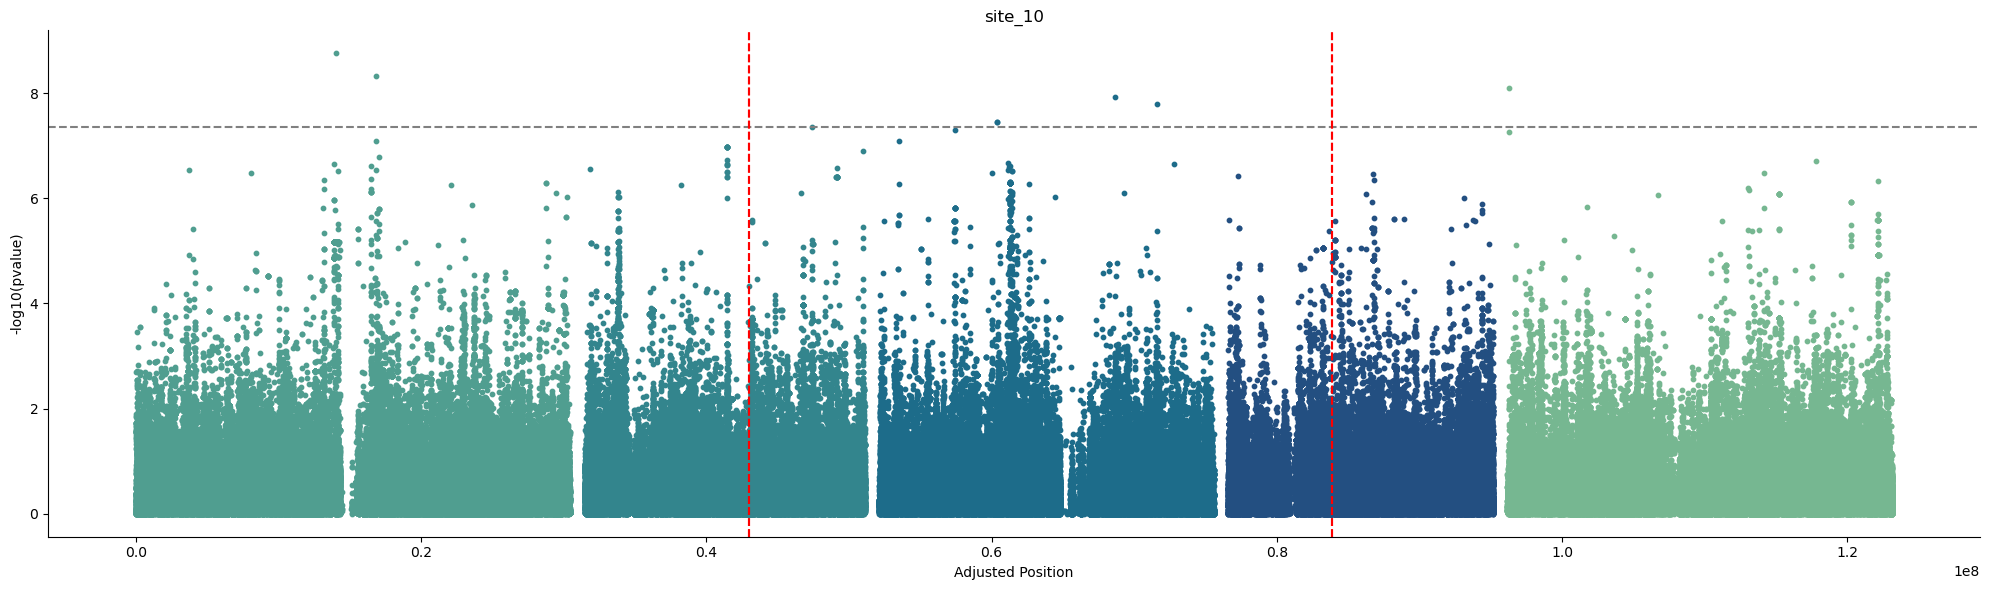

/tmp/ipykernel_78550/1658760834.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


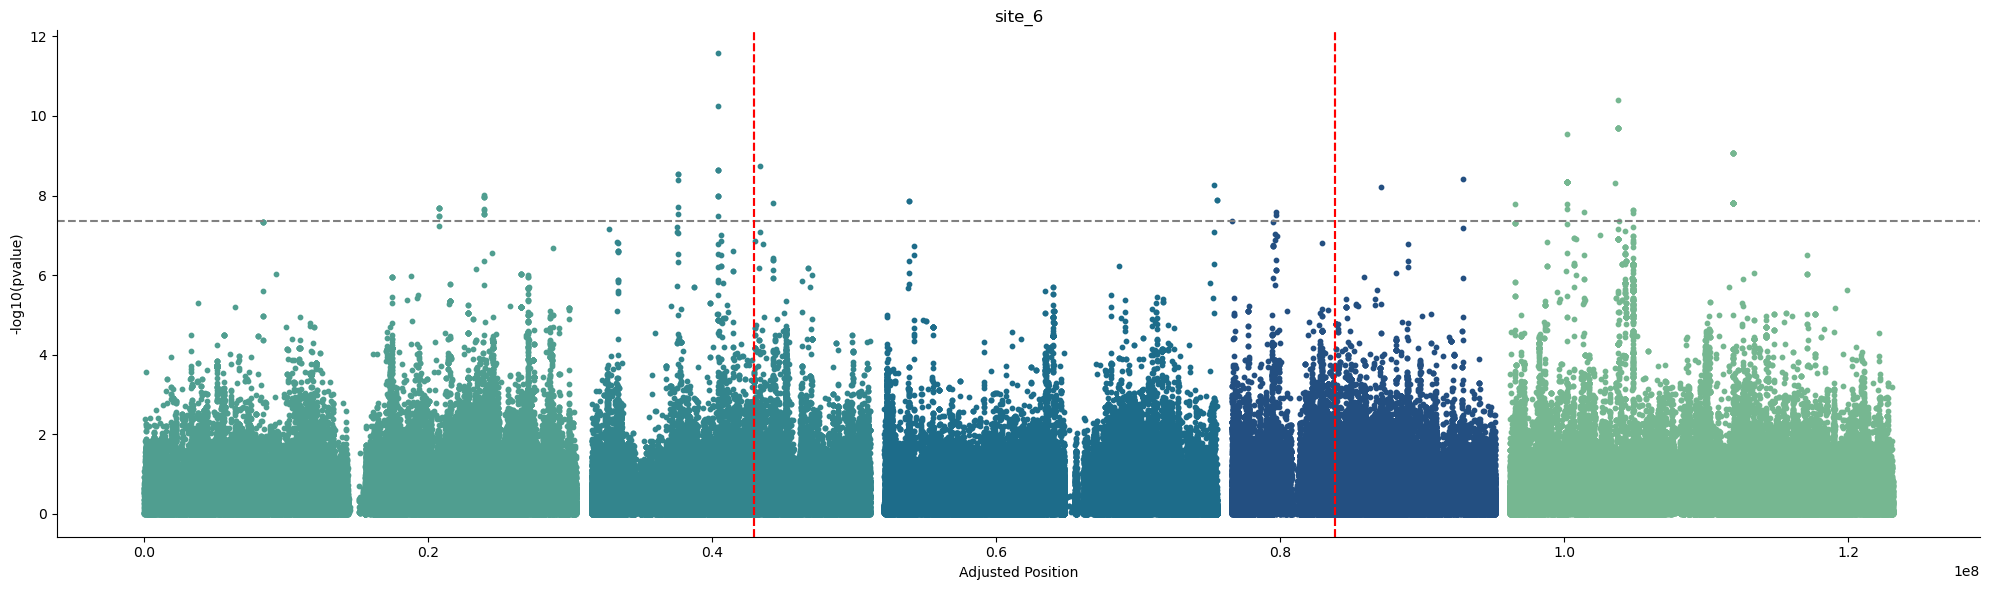

/tmp/ipykernel_78550/1658760834.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


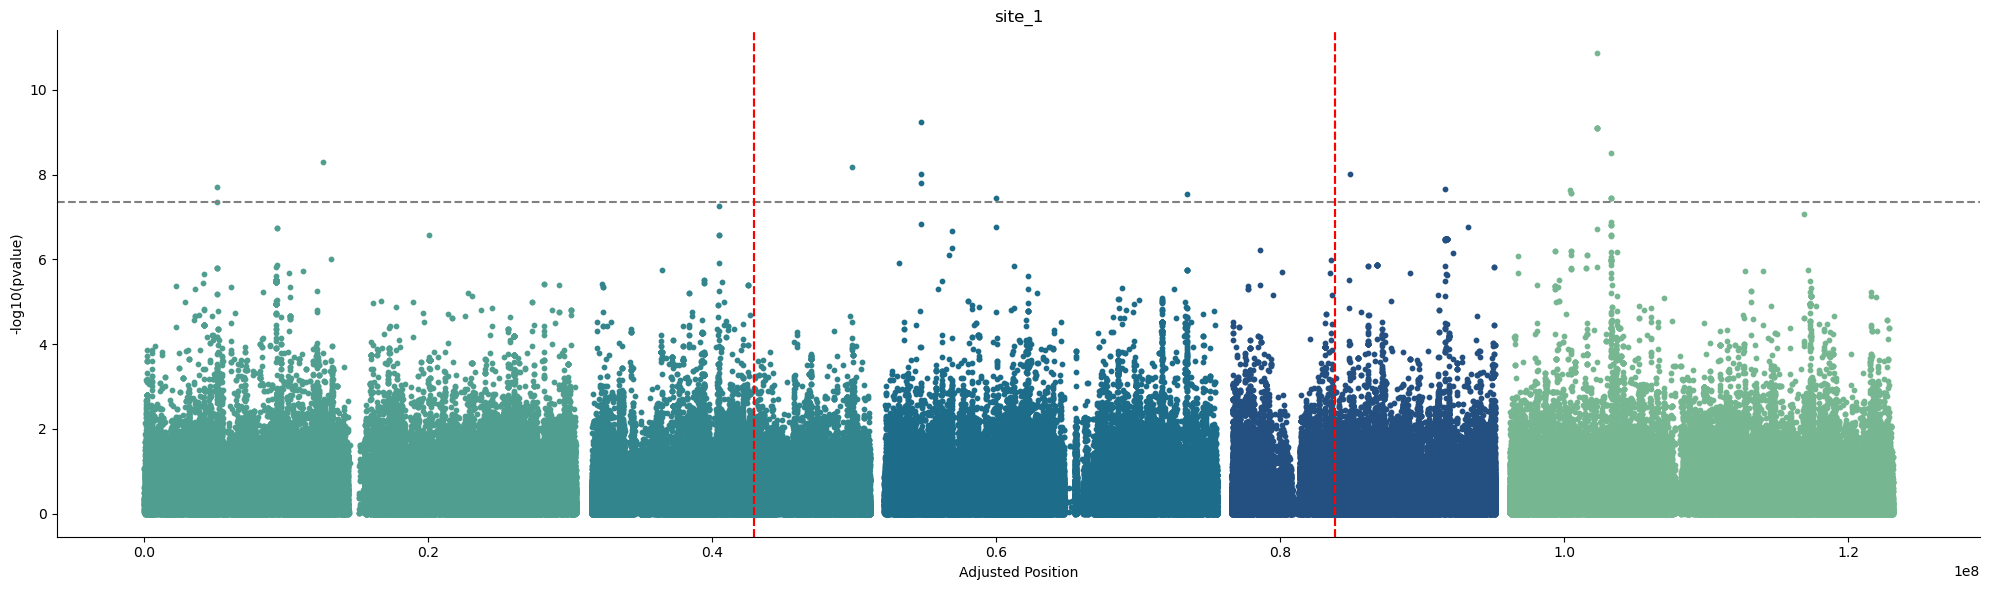

/tmp/ipykernel_78550/1658760834.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


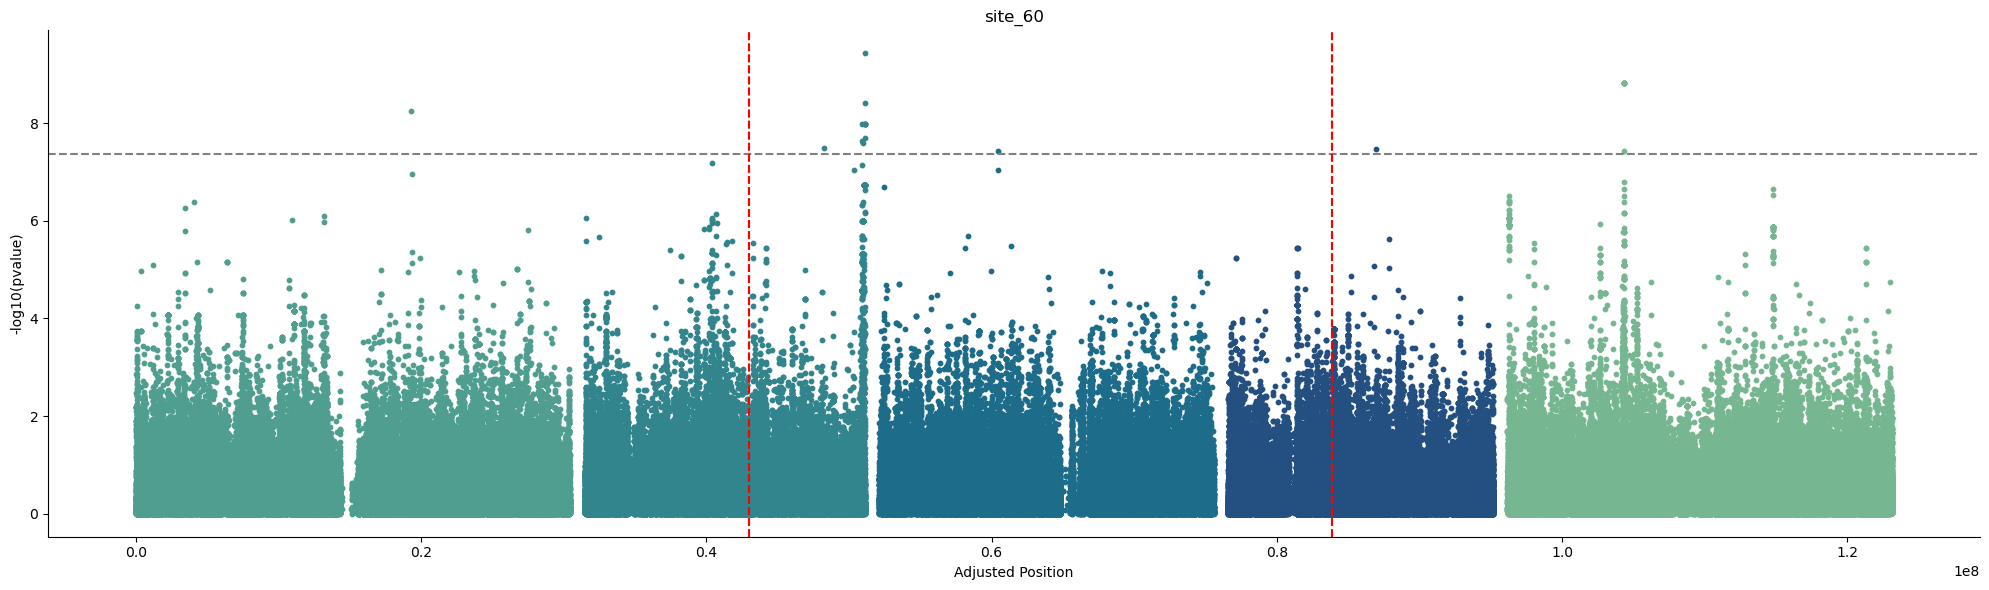

/tmp/ipykernel_78550/1658760834.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


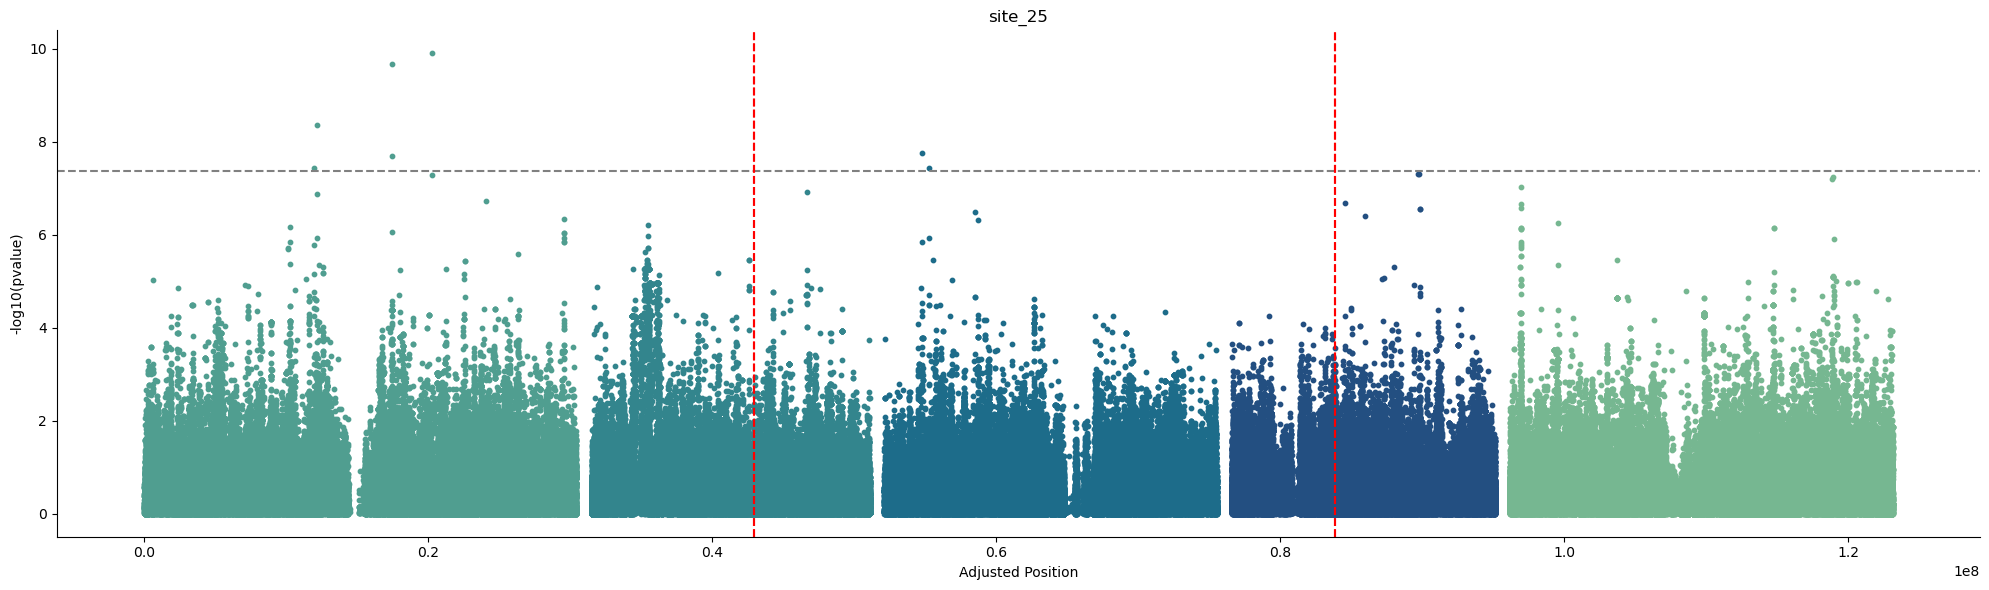

/tmp/ipykernel_78550/1658760834.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


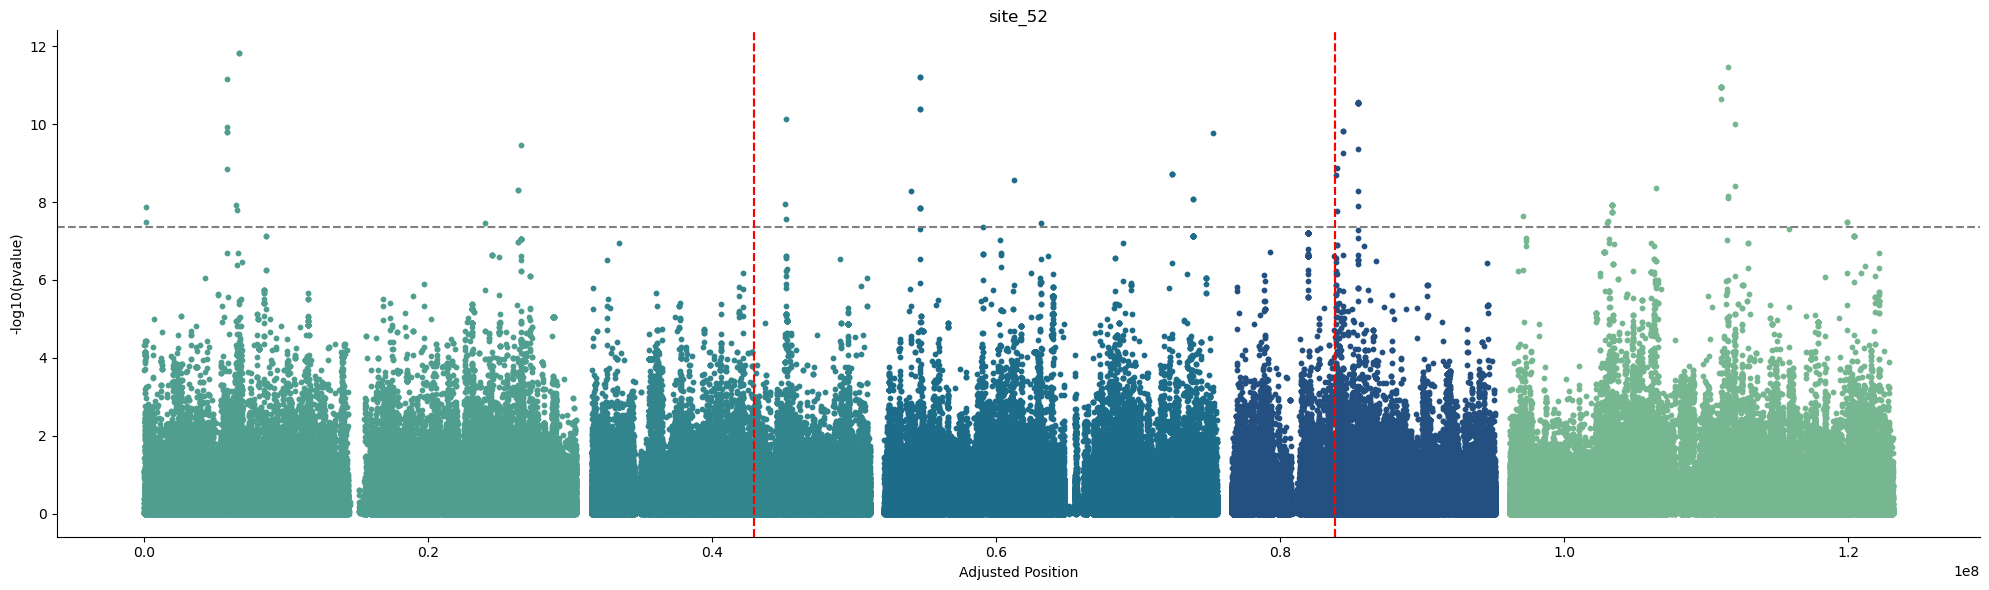

/tmp/ipykernel_78550/1658760834.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


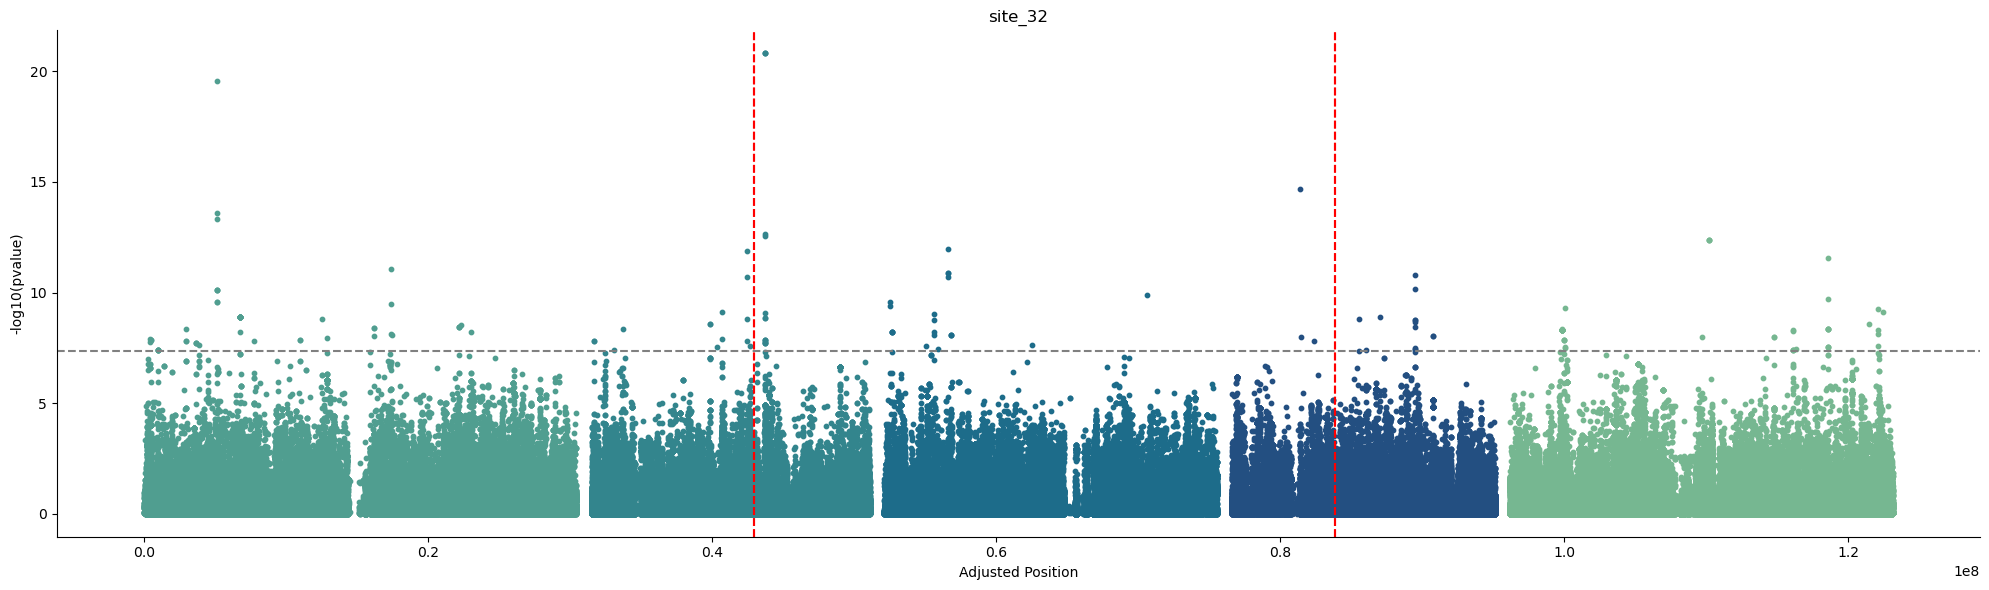

/tmp/ipykernel_78550/1658760834.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


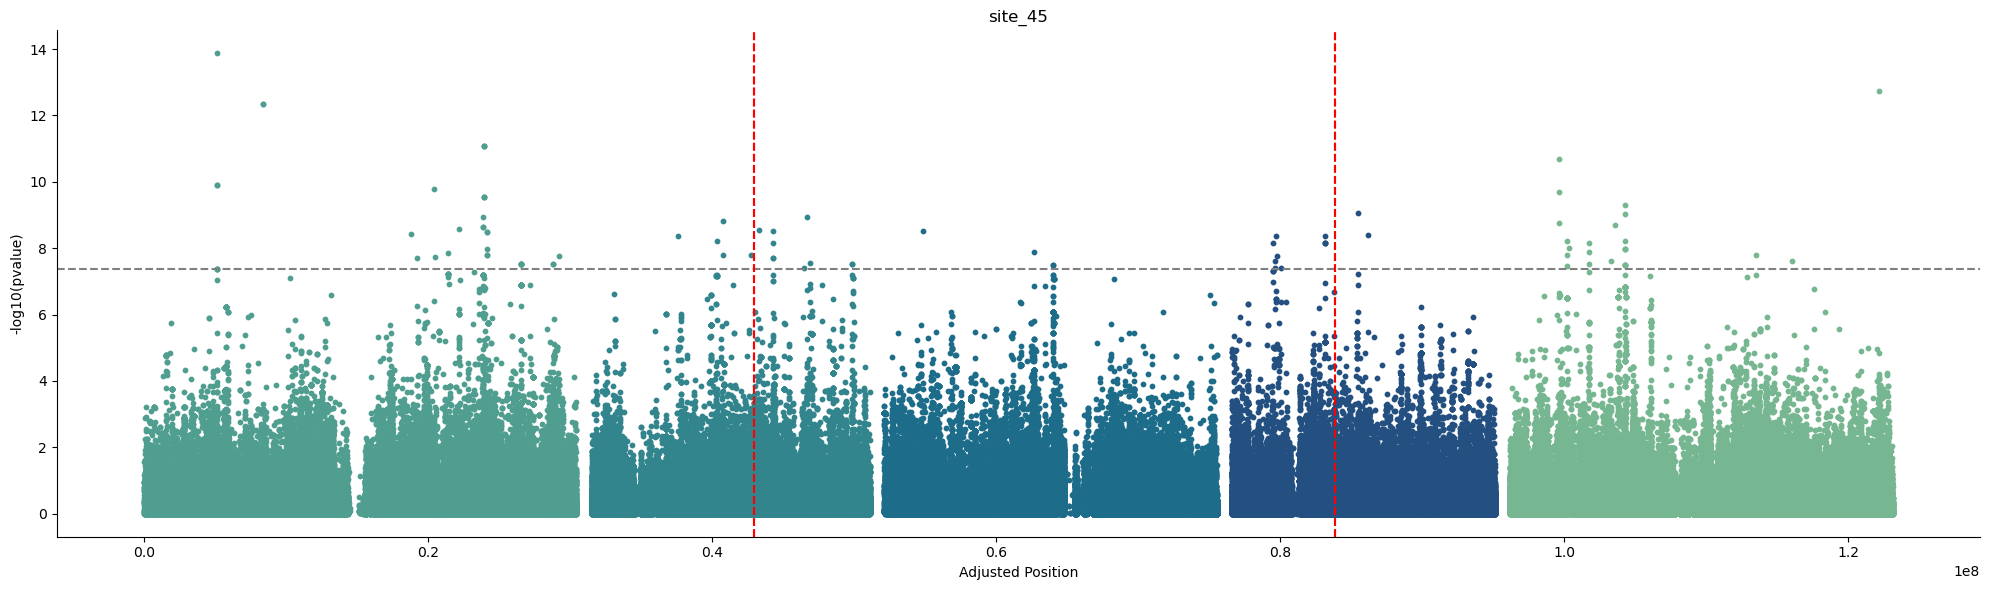

/tmp/ipykernel_78550/1658760834.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


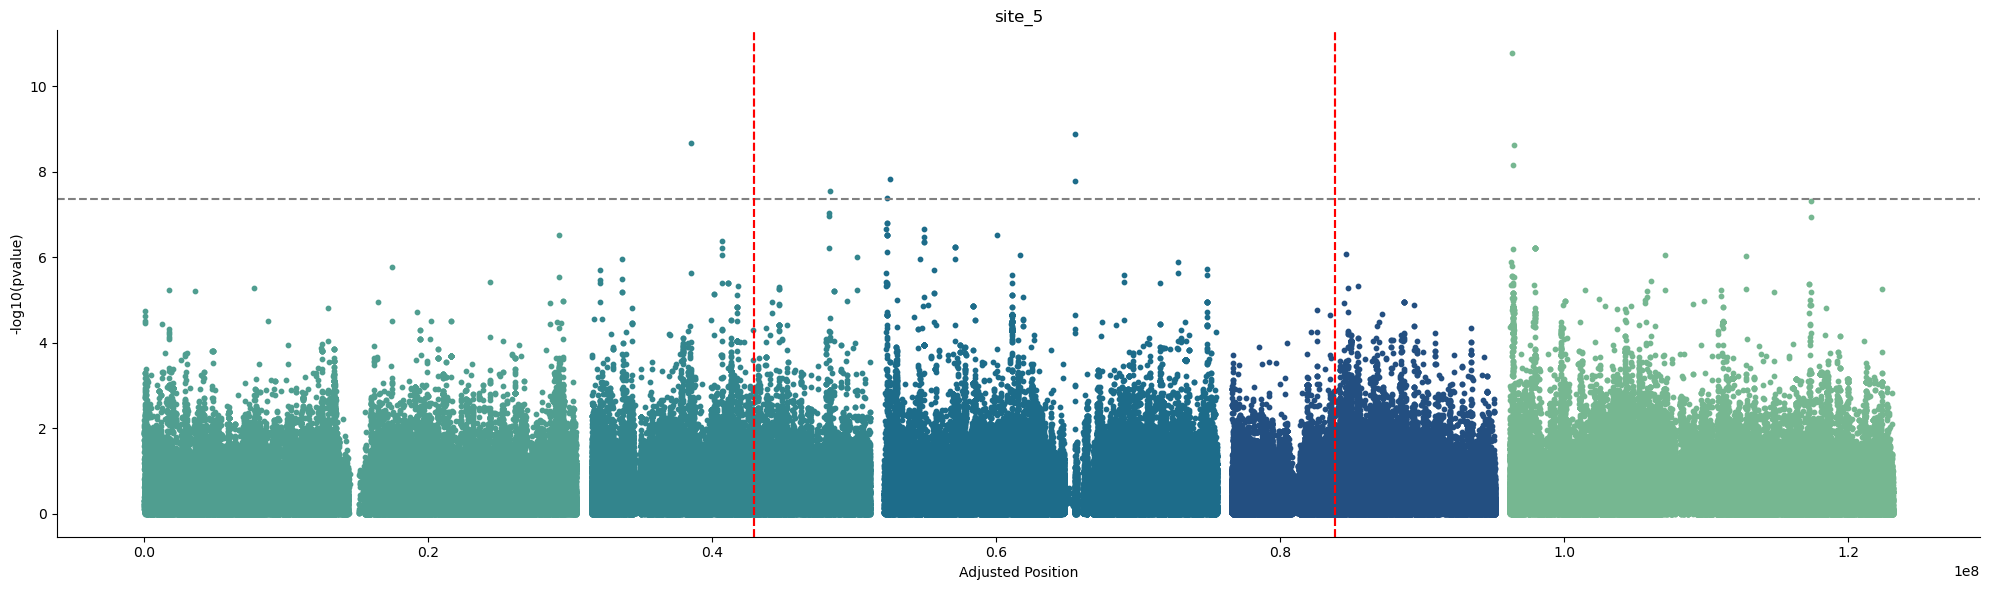

/tmp/ipykernel_78550/1658760834.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


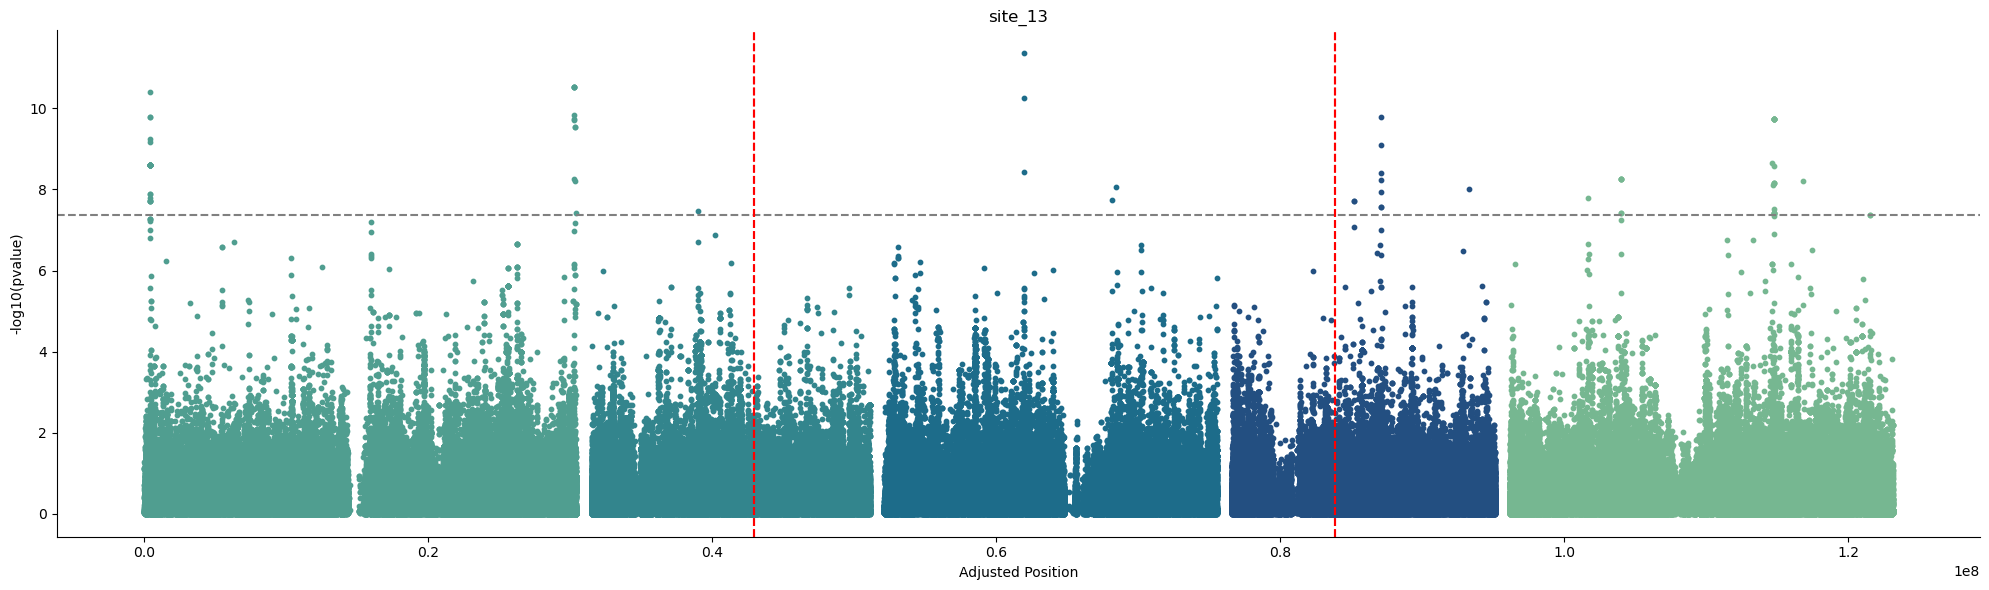

/tmp/ipykernel_78550/1658760834.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


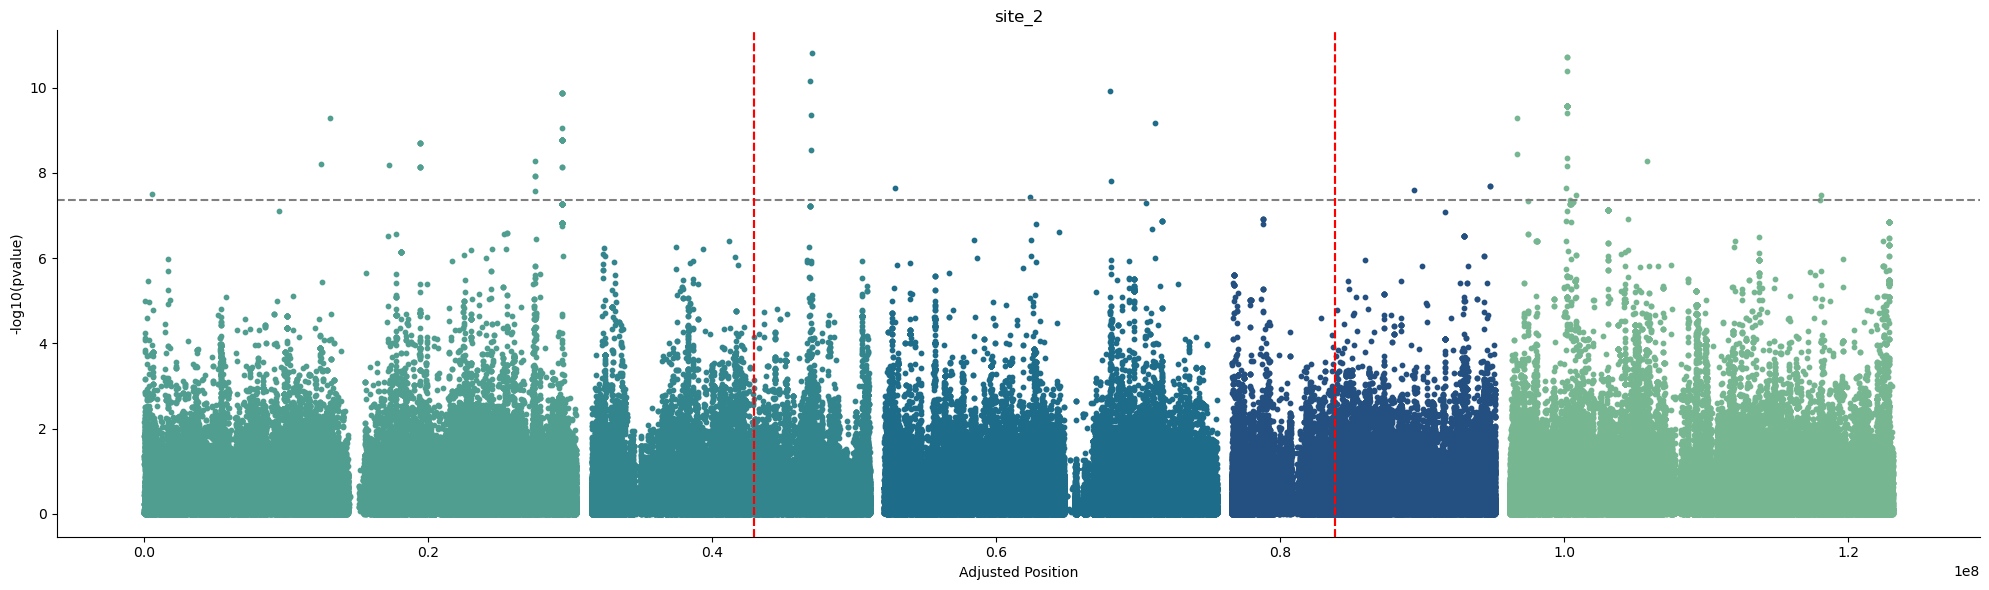

/tmp/ipykernel_78550/1658760834.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


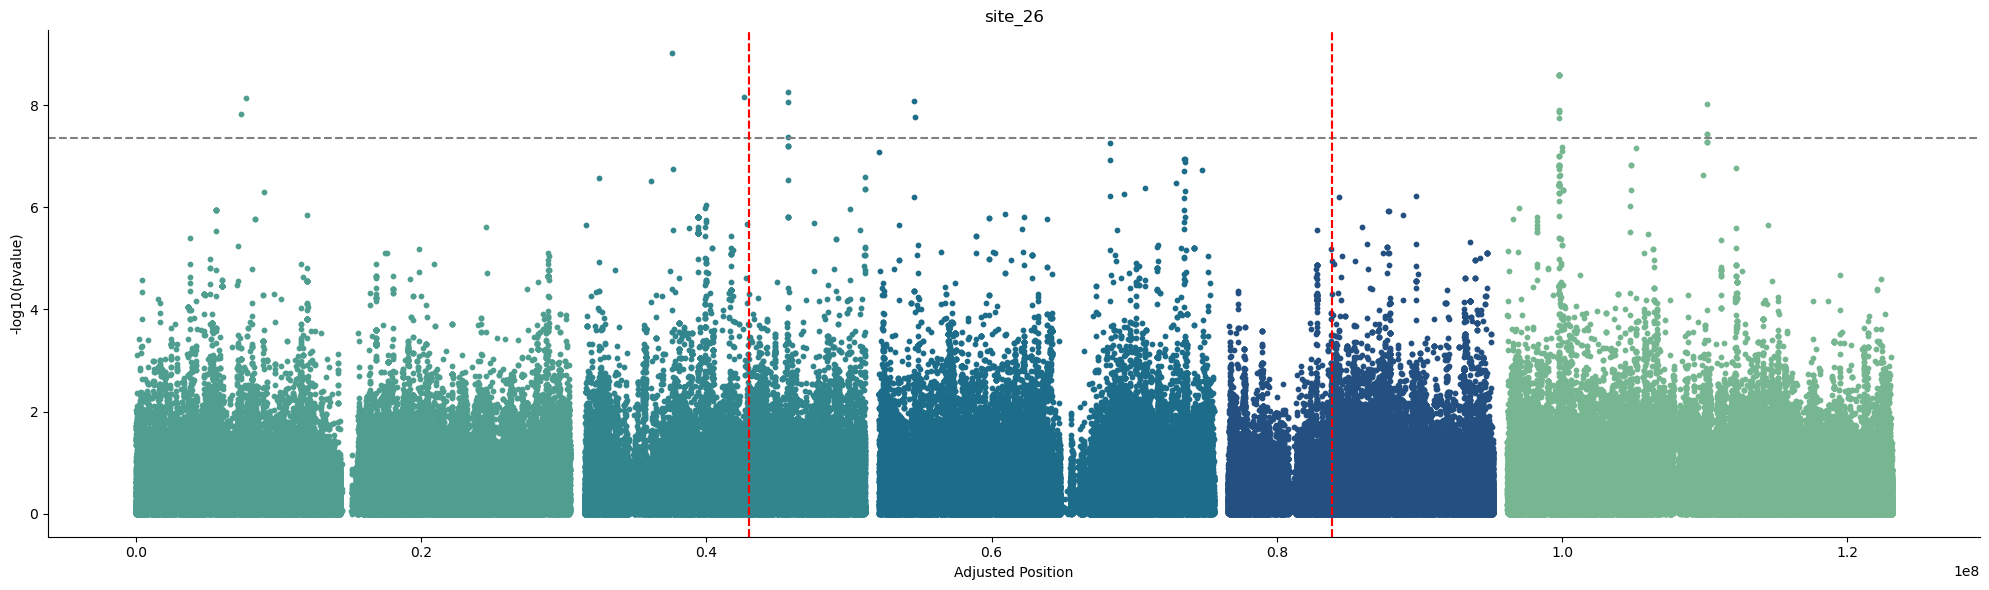

/tmp/ipykernel_78550/1658760834.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


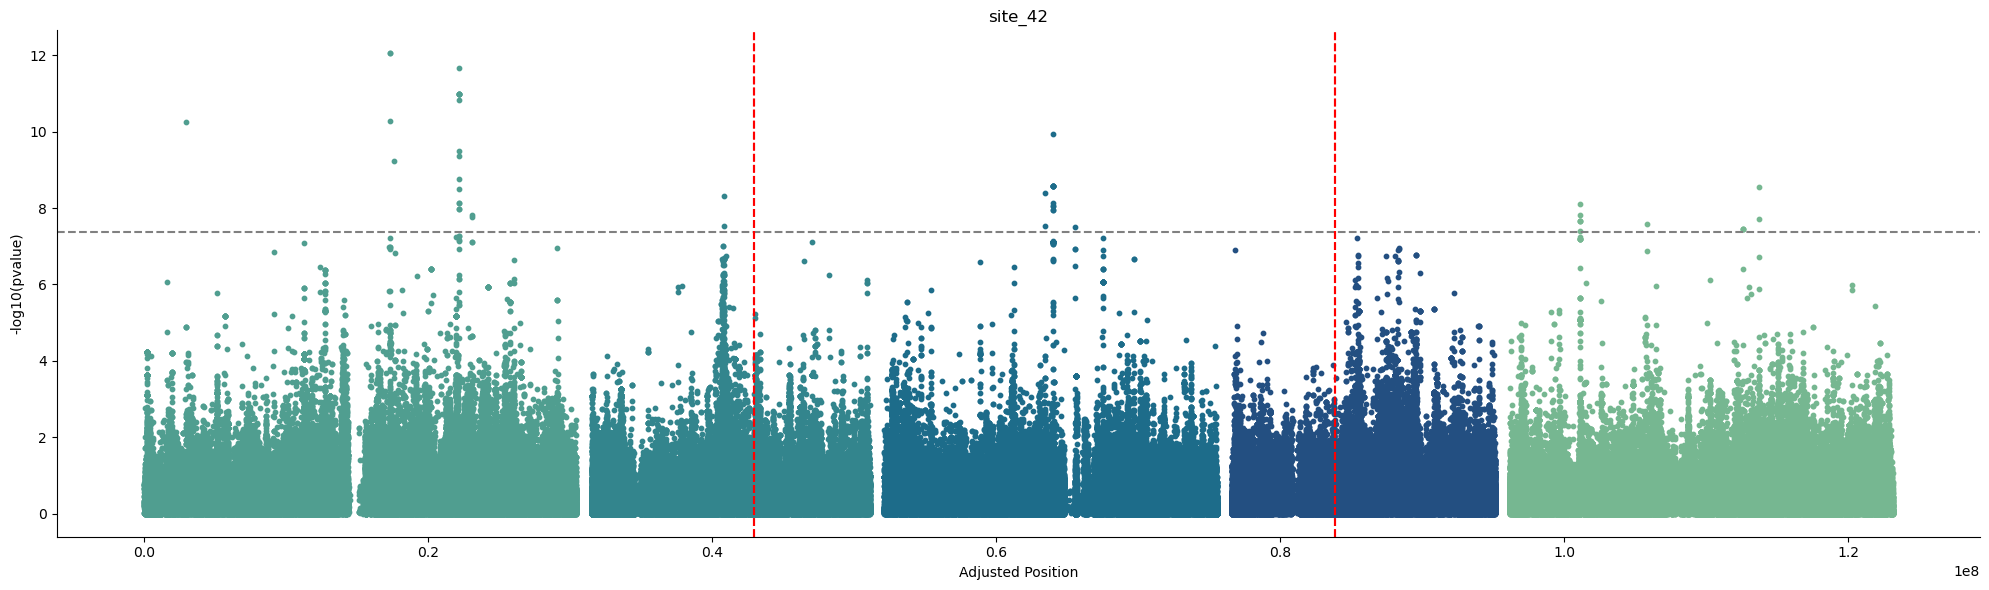

/tmp/ipykernel_78550/1658760834.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


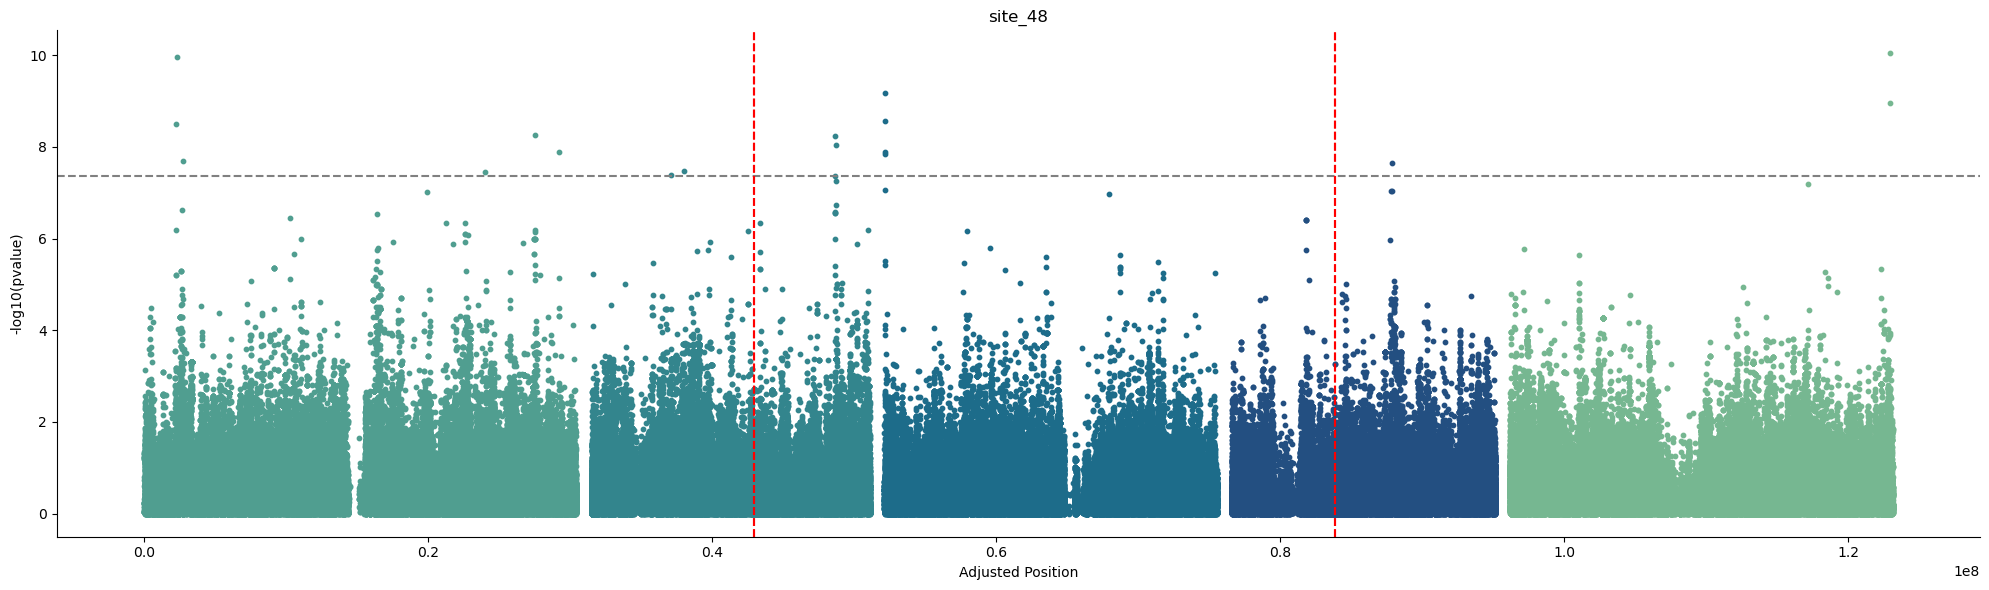

/tmp/ipykernel_78550/1658760834.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


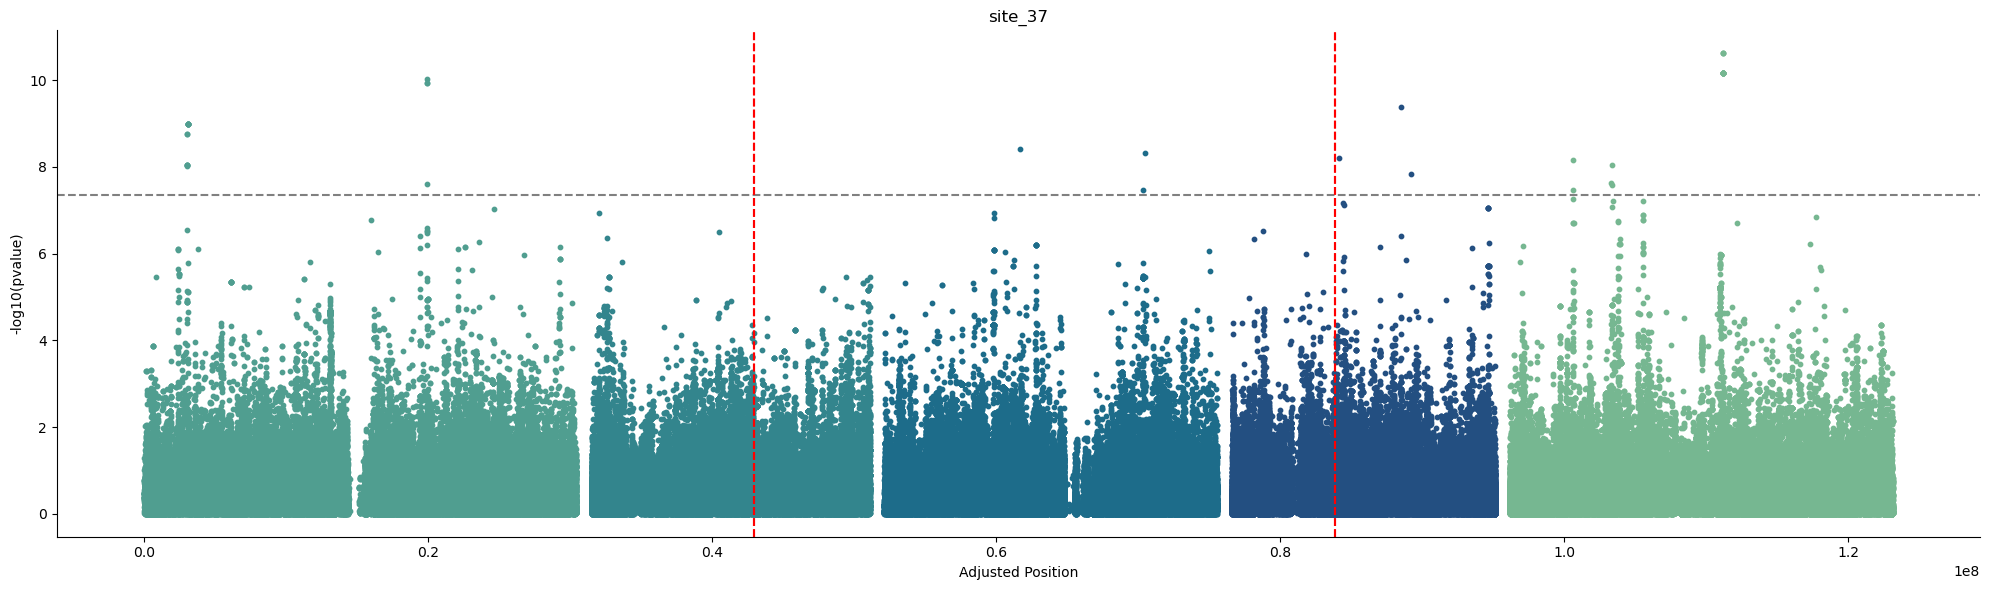

/tmp/ipykernel_78550/1658760834.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


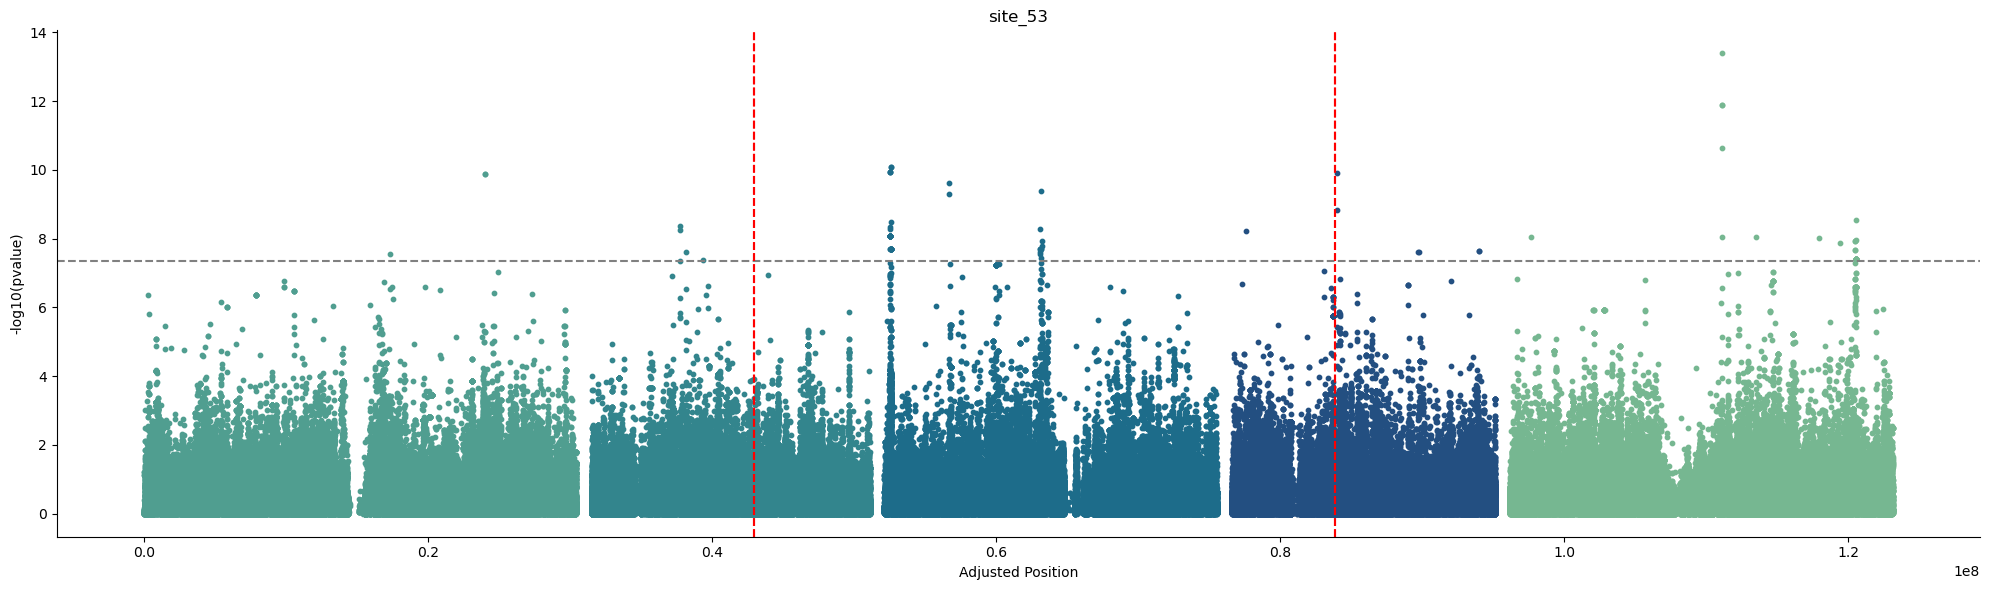

/tmp/ipykernel_78550/1658760834.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


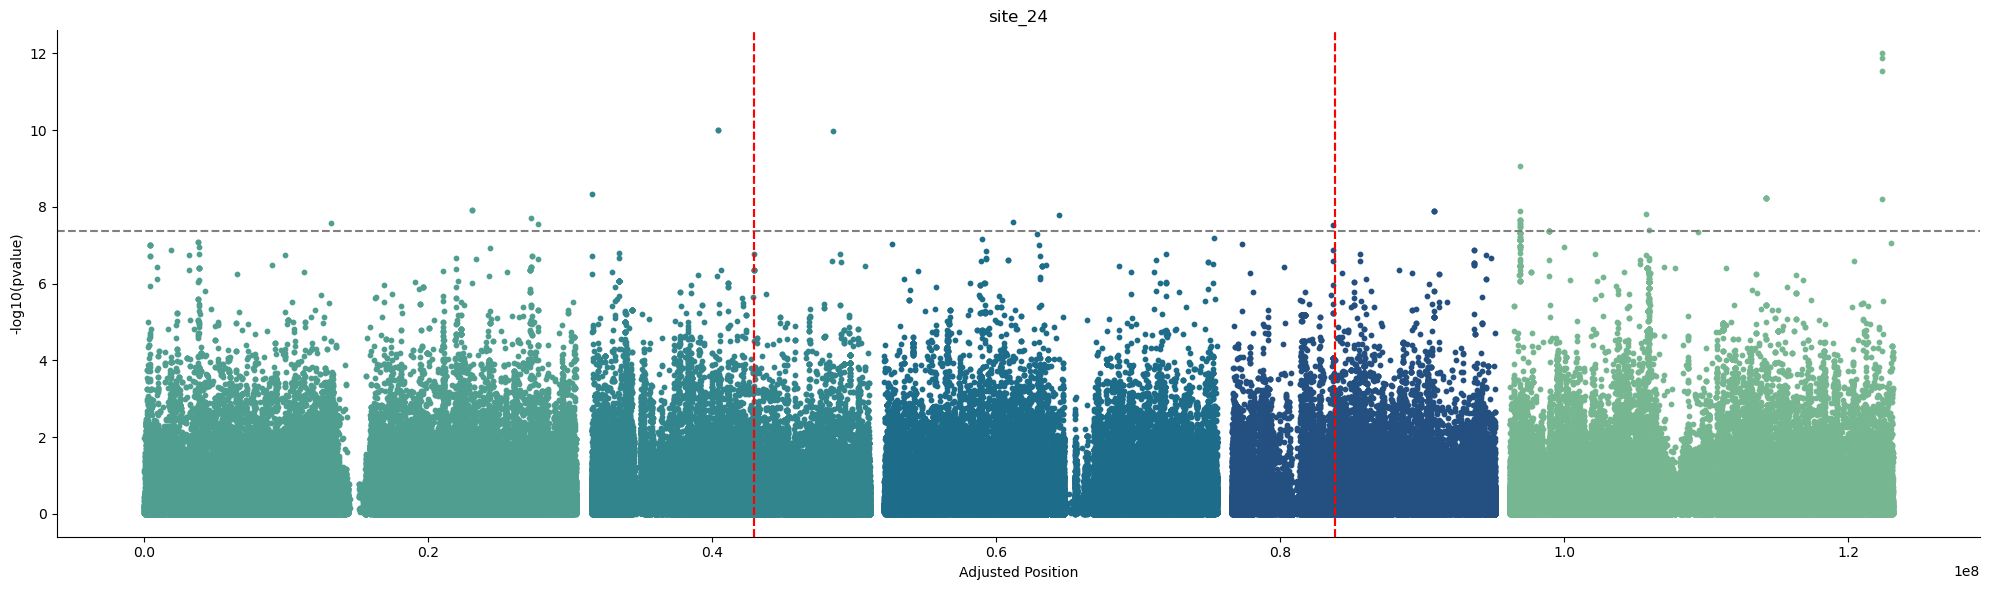

/tmp/ipykernel_78550/1658760834.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


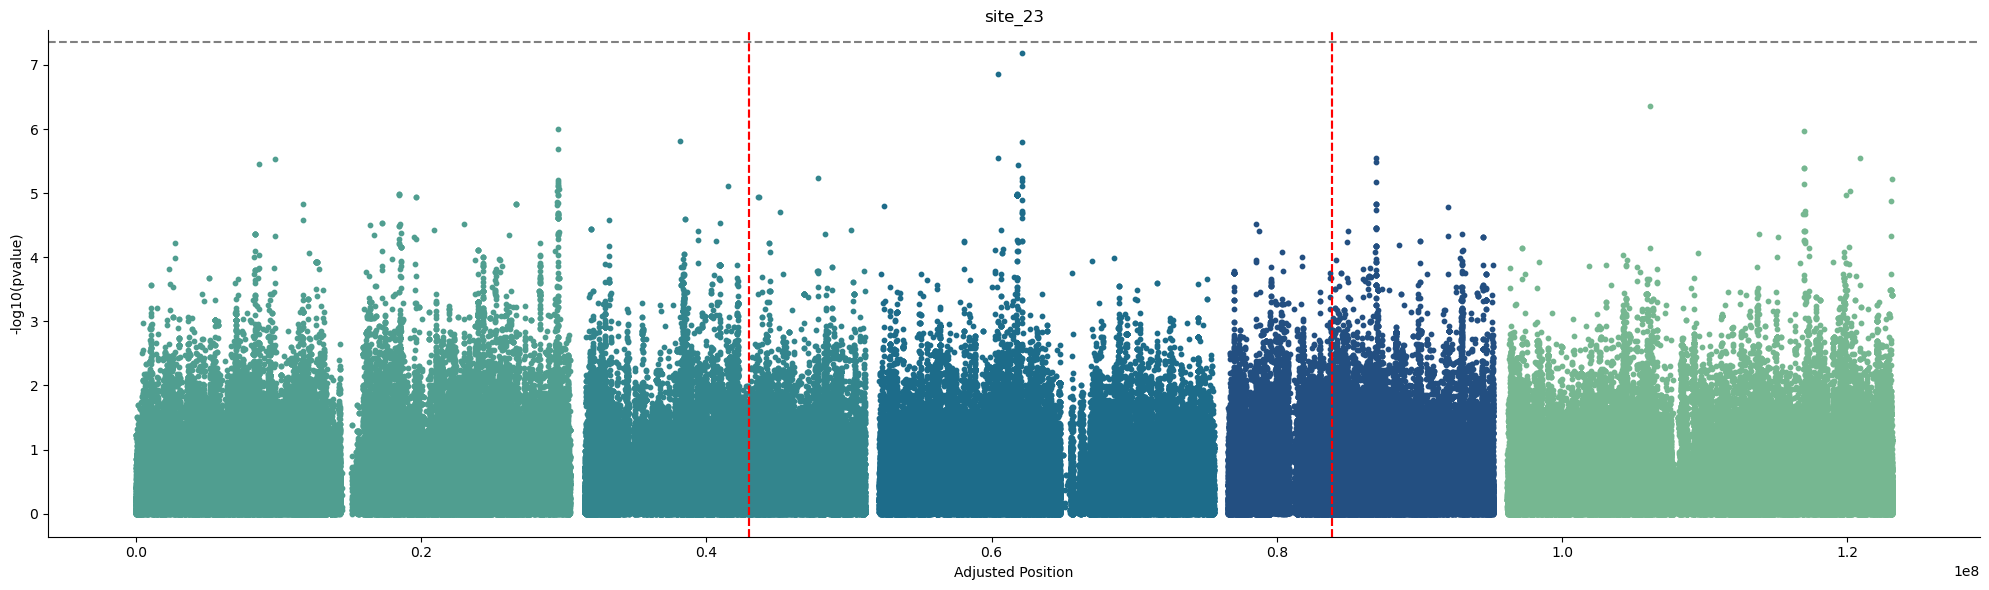

/tmp/ipykernel_78550/1658760834.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


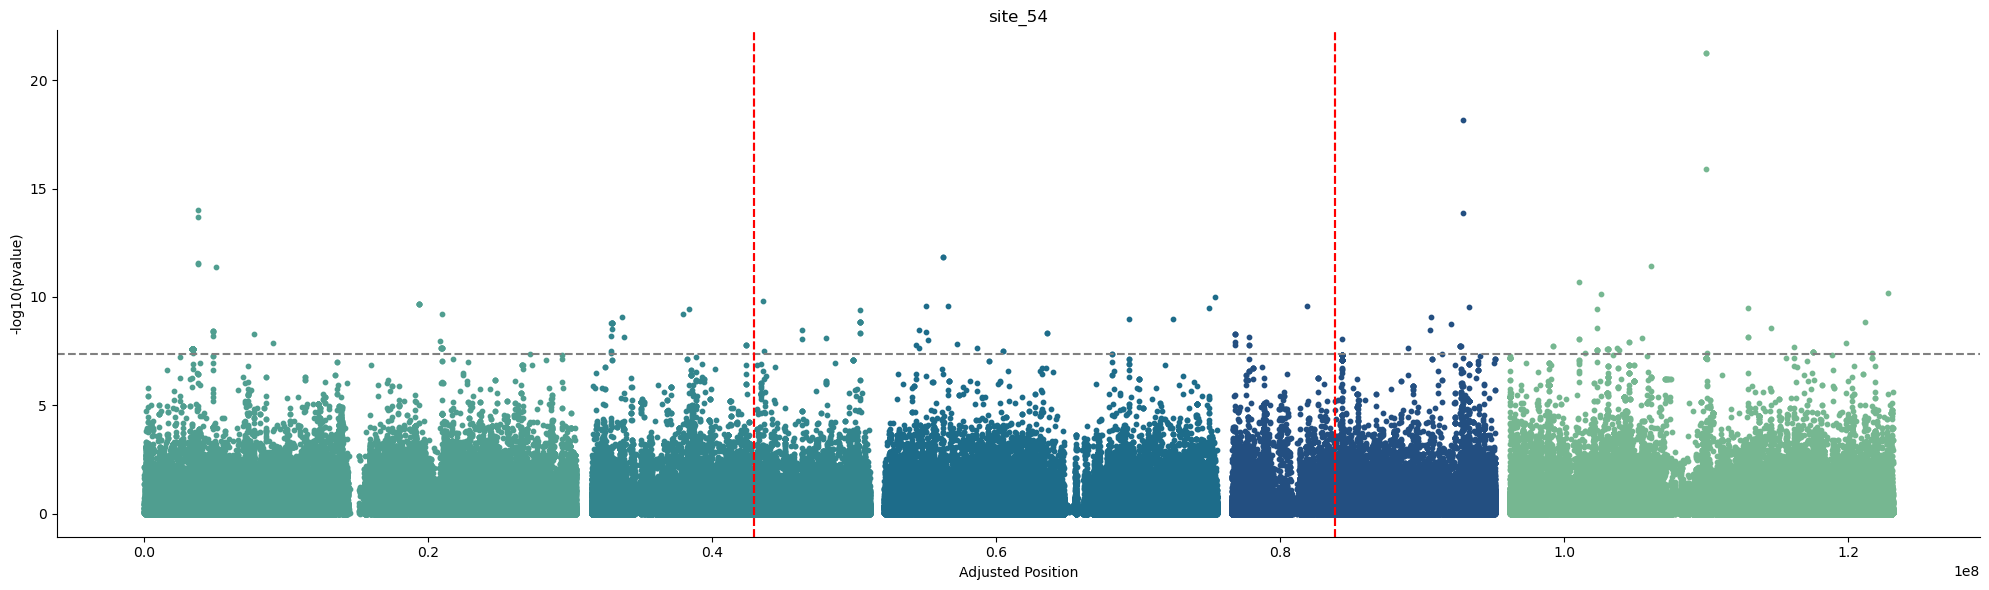

/tmp/ipykernel_78550/1658760834.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


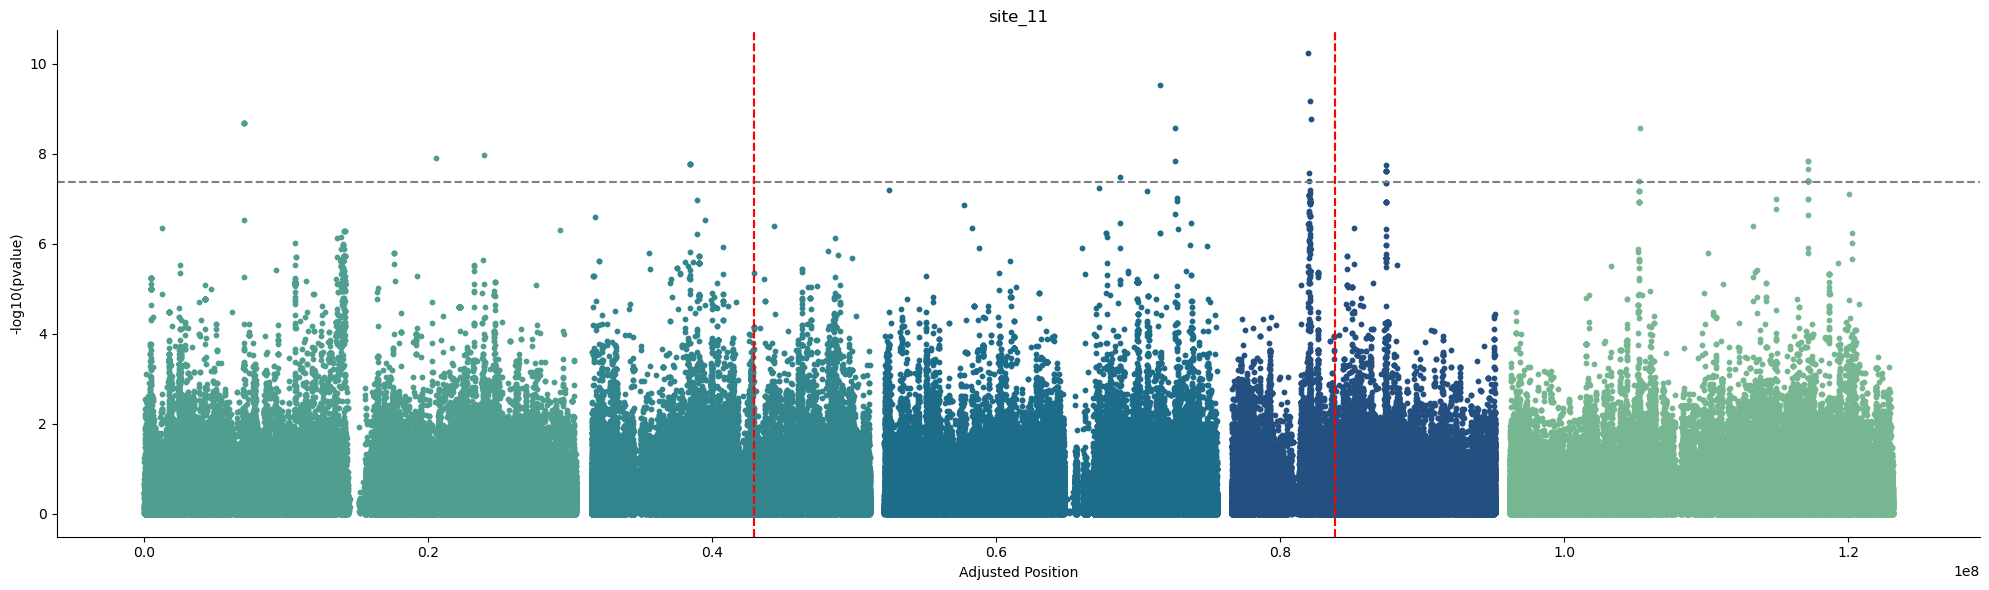

/tmp/ipykernel_78550/1658760834.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


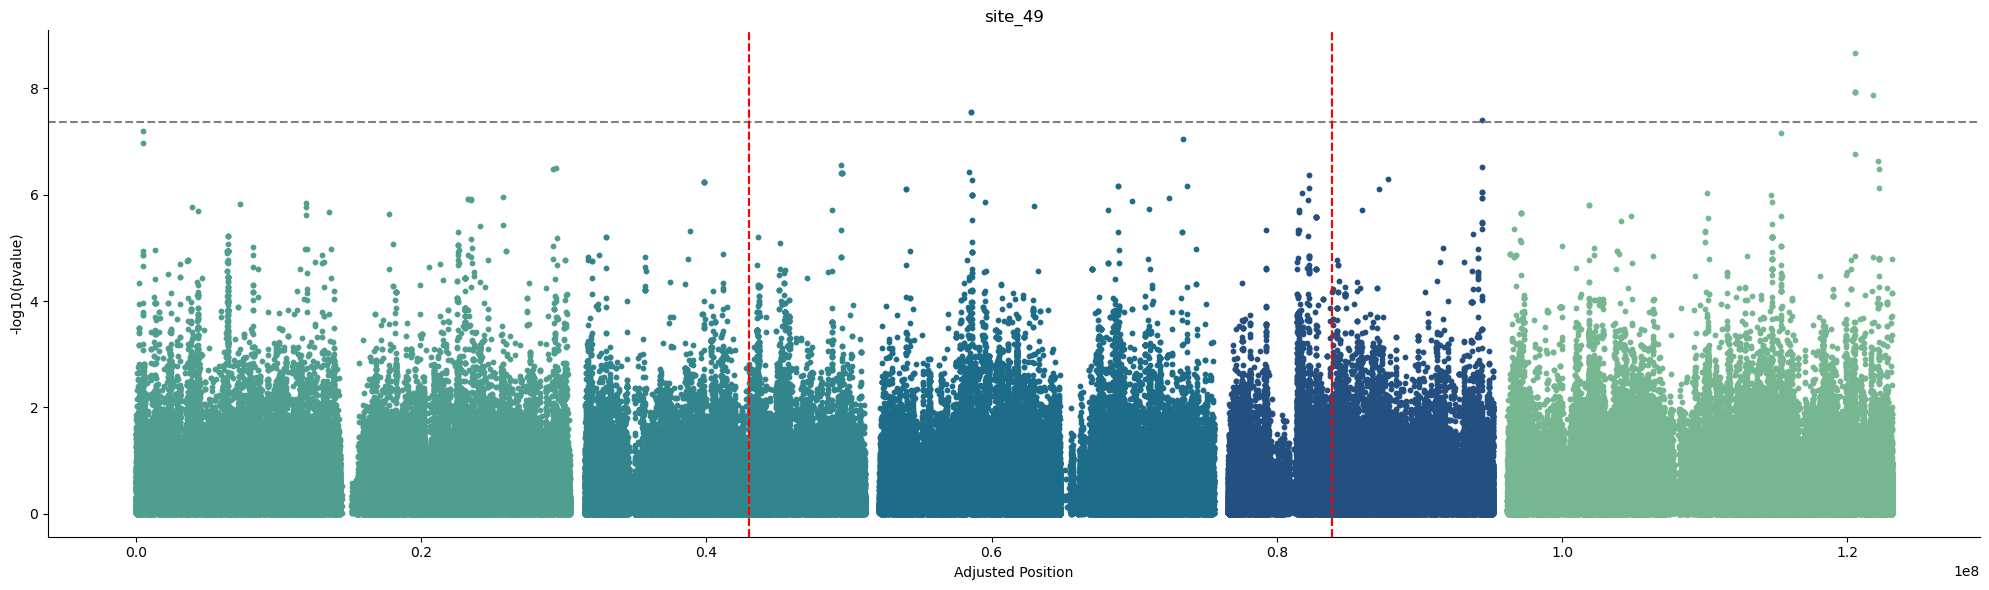

/tmp/ipykernel_78550/1658760834.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


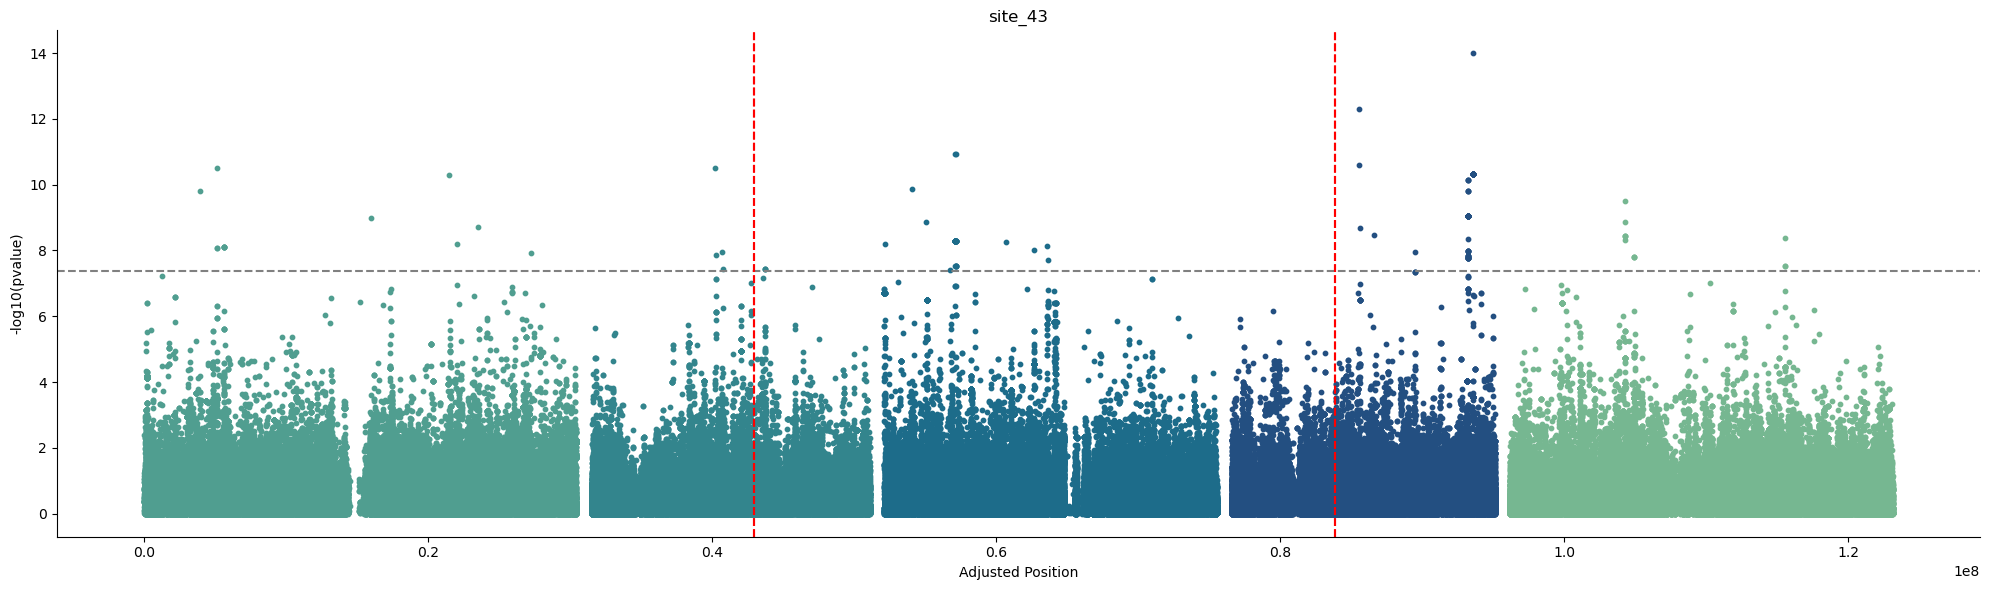

/tmp/ipykernel_78550/1658760834.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


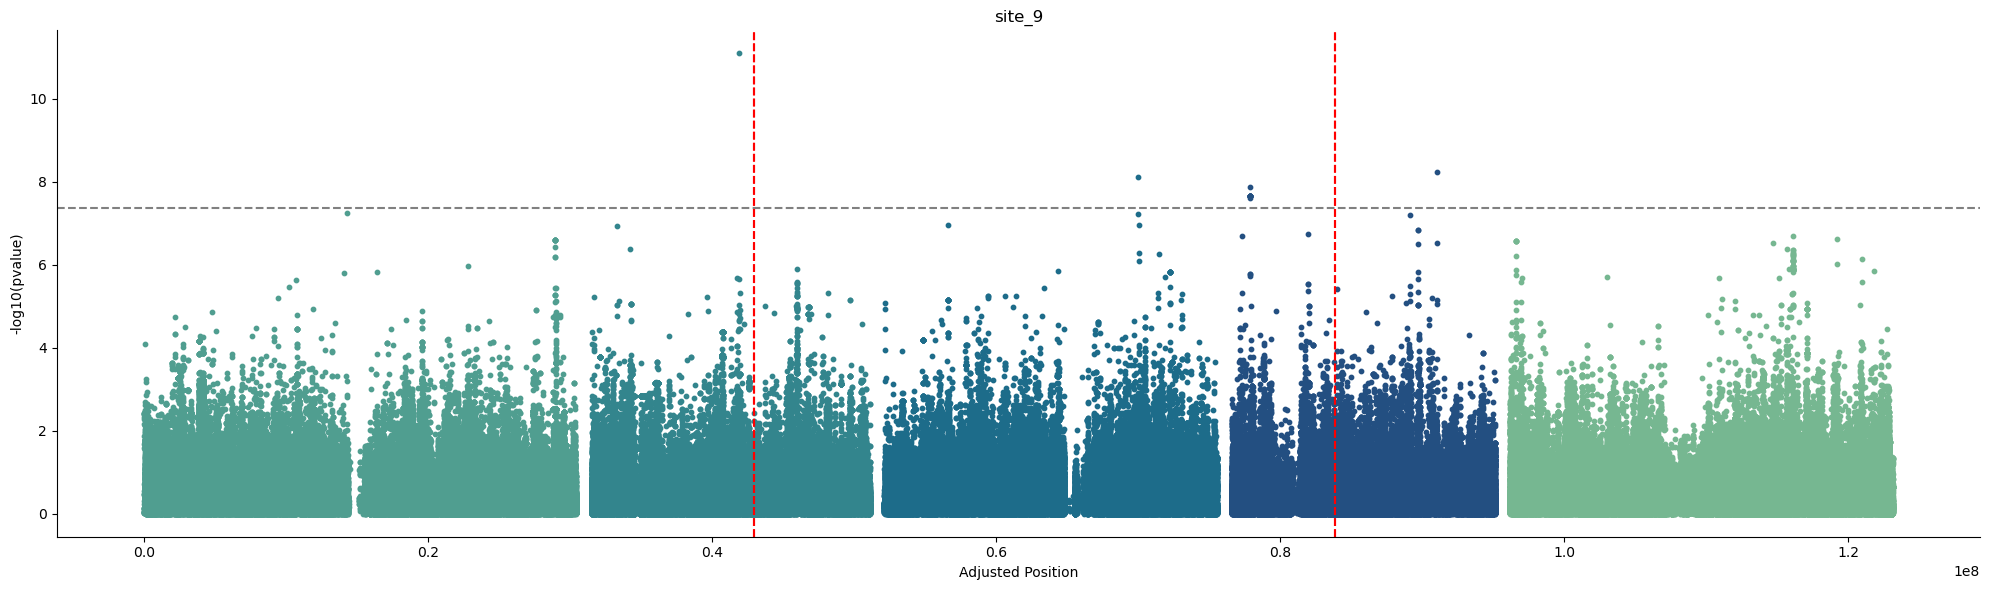

/tmp/ipykernel_78550/1658760834.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


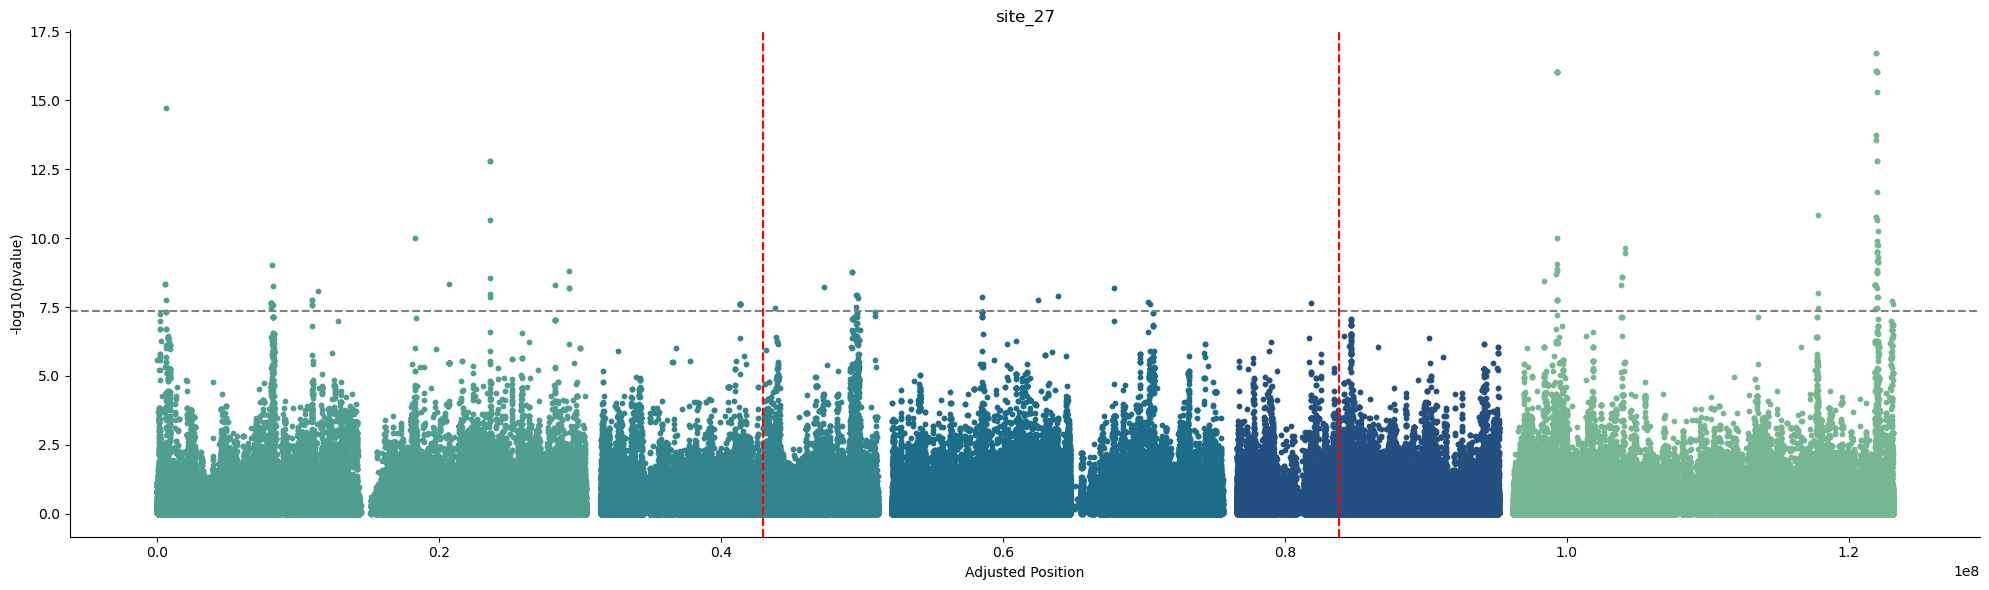

/tmp/ipykernel_78550/1658760834.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


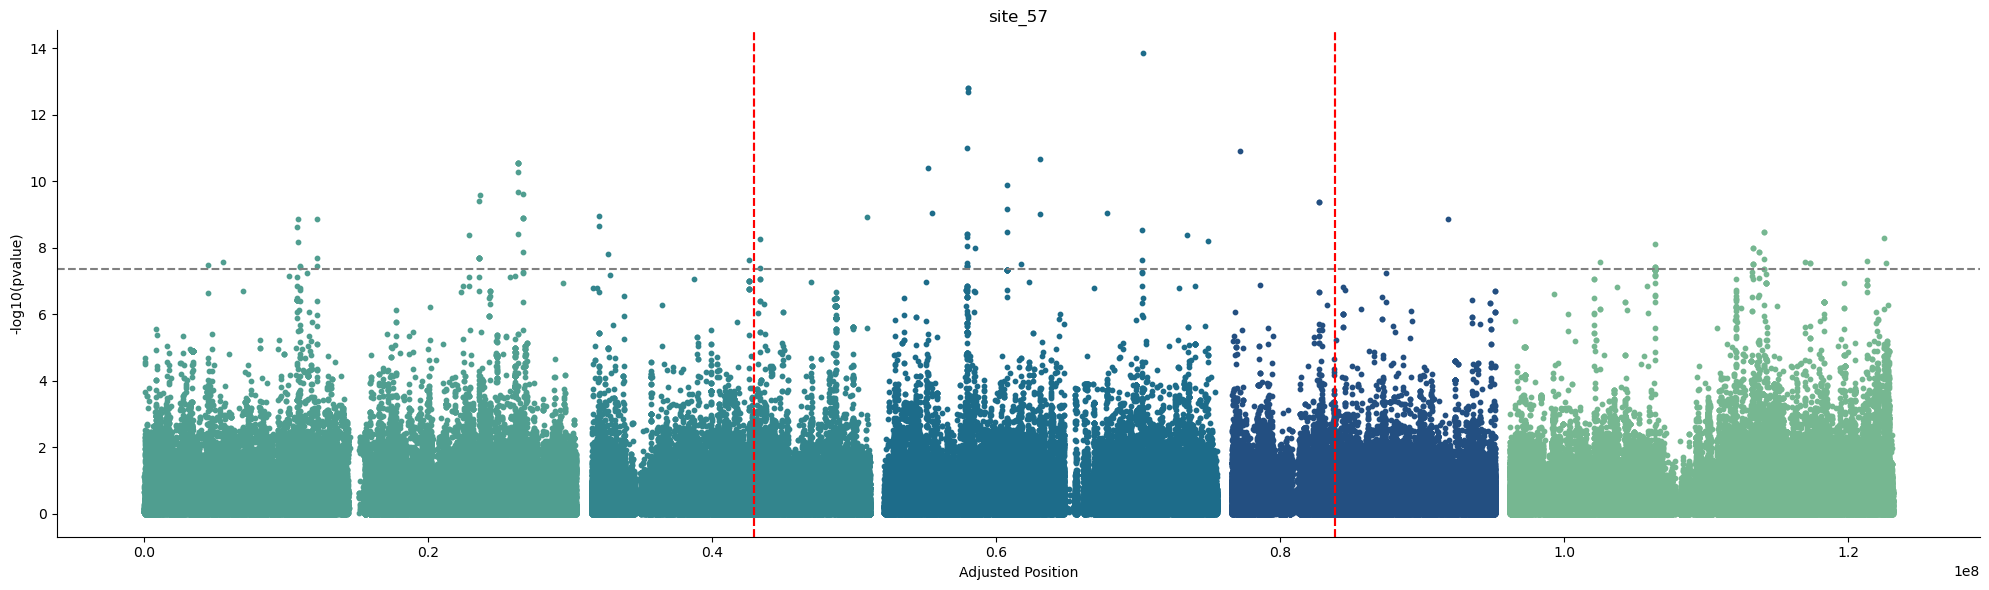

/tmp/ipykernel_78550/1658760834.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


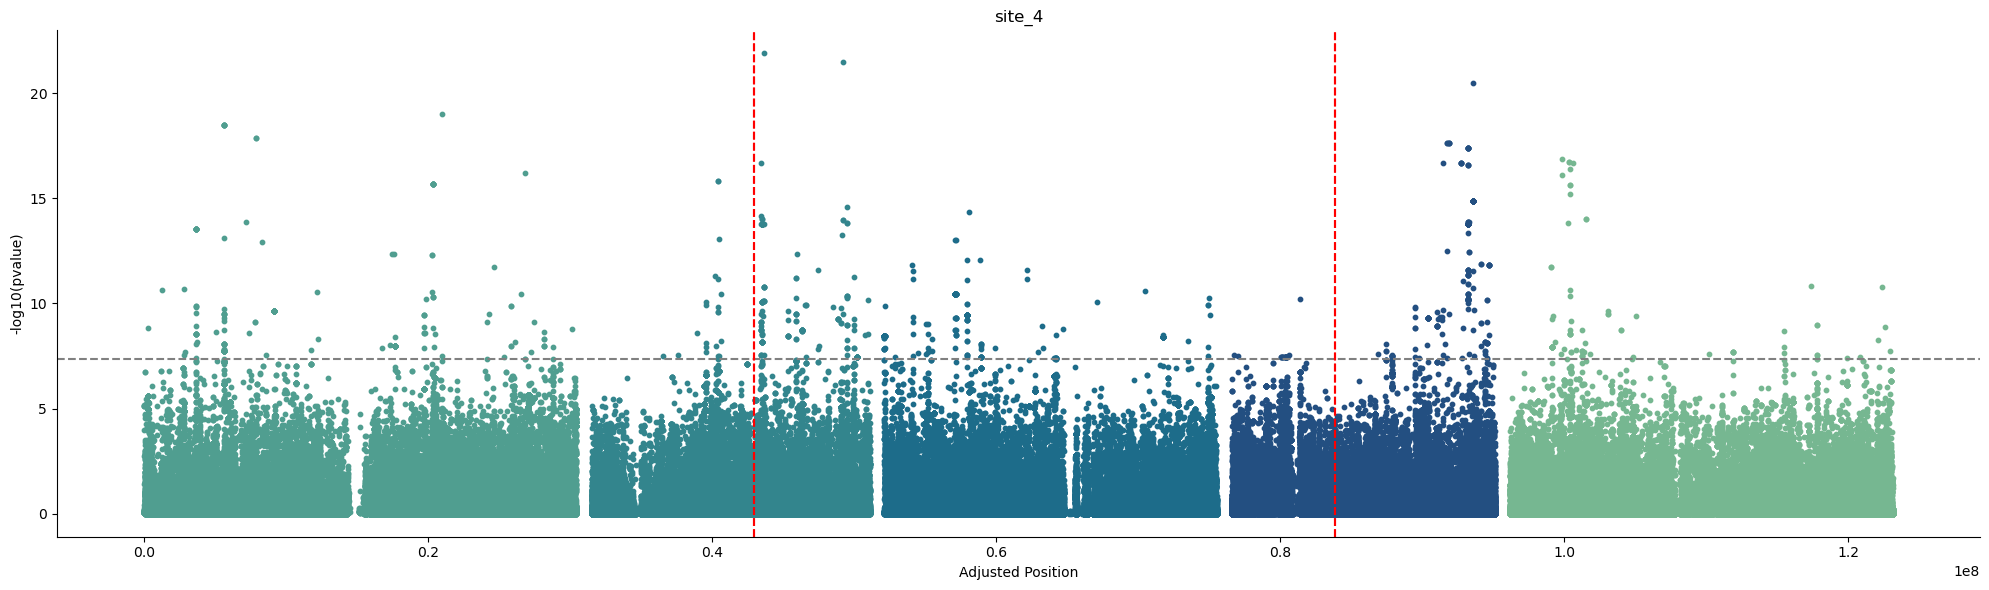

/tmp/ipykernel_78550/1658760834.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


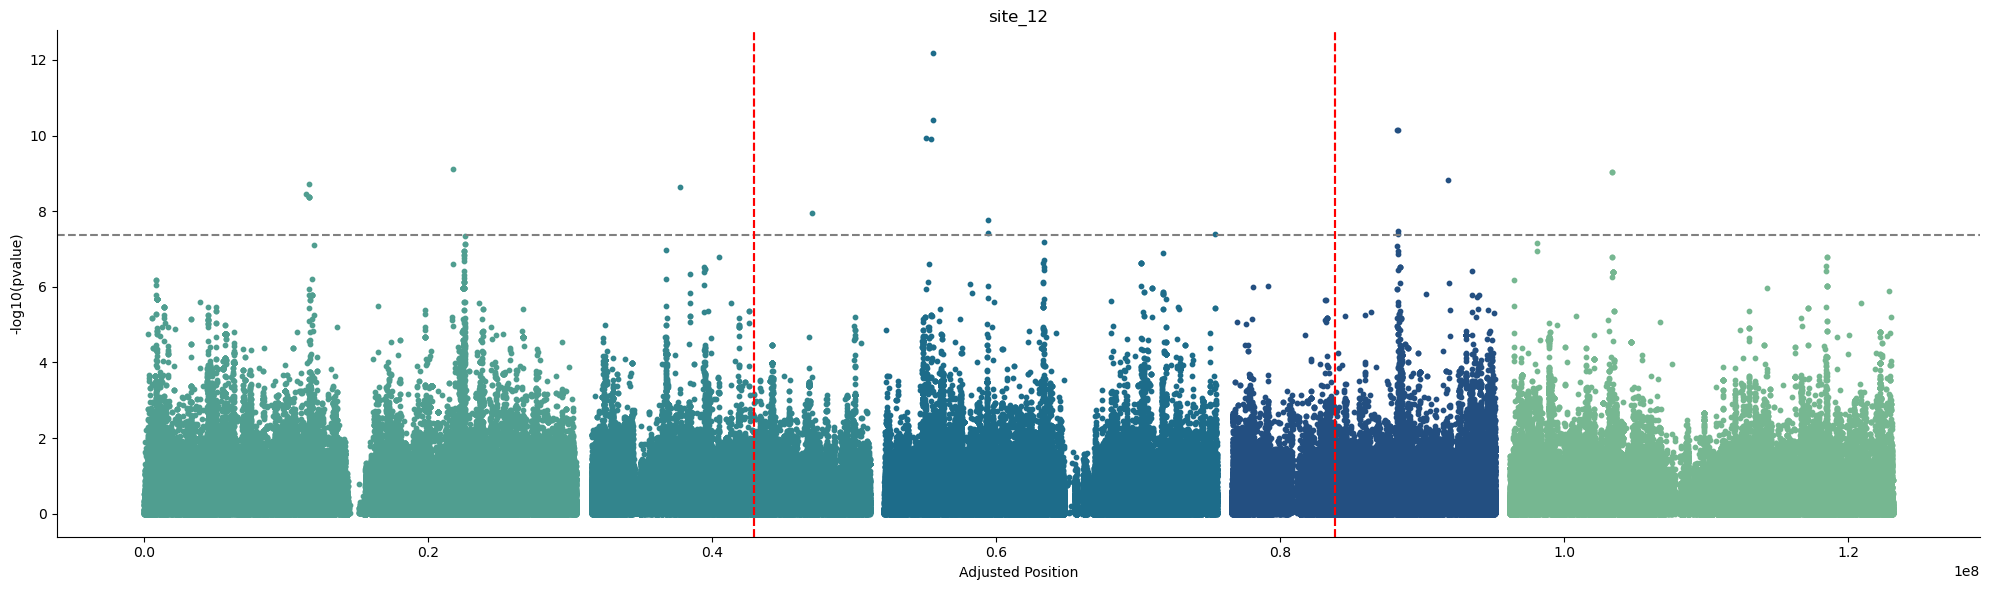

/tmp/ipykernel_78550/1658760834.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)


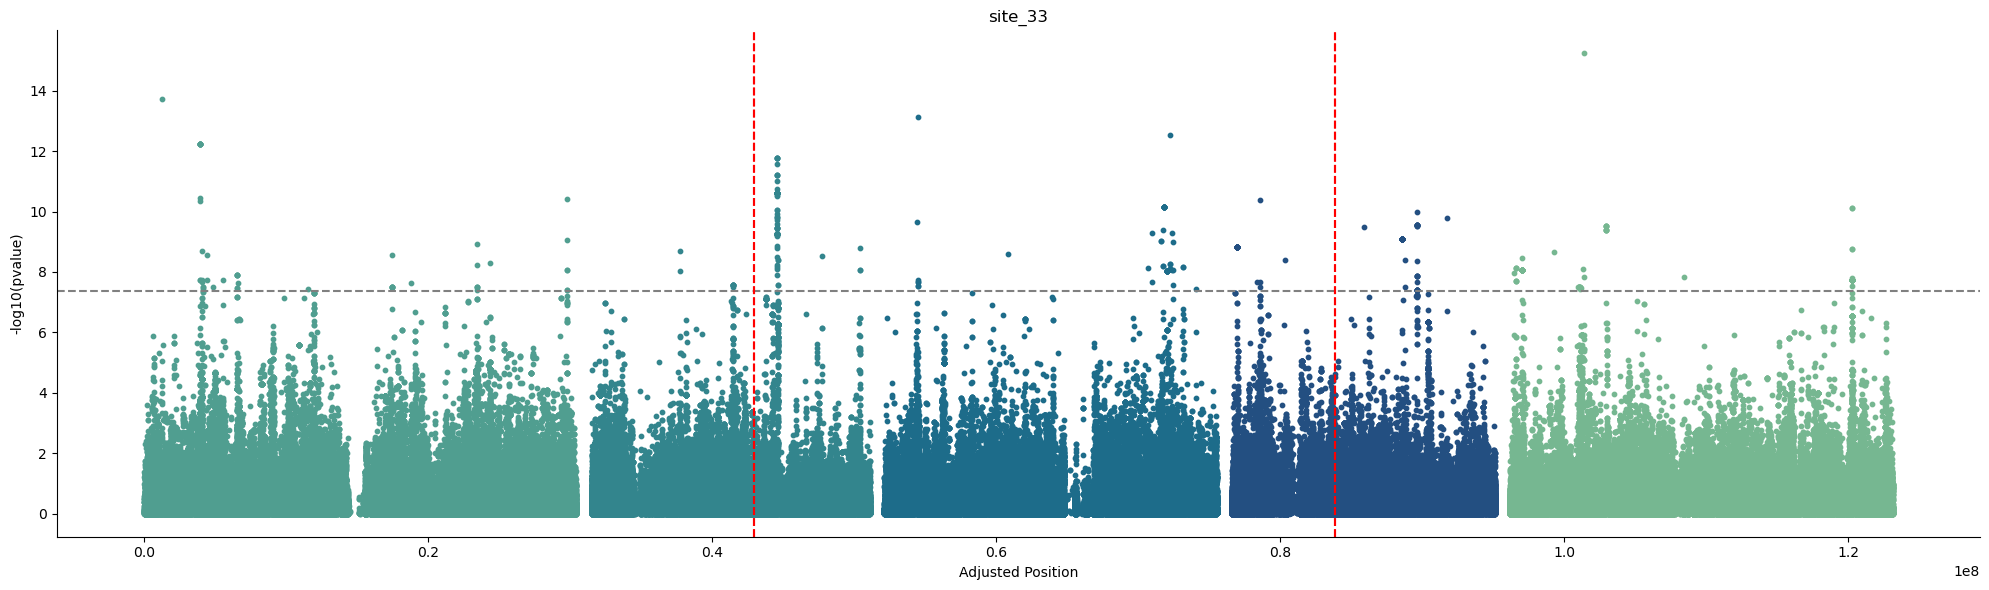

In [185]:
for site in sites:
    pvalues_file = path + f'/{site}/output/results_lmm.csv'
    
    pvalues = dd.read_csv(pvalues_file)
    pvalues = pvalues.compute()
    
    pvalues.columns = ['id', 'pvalue','beta', 'significant', 'blocks', 'MAF']
    
    threshold_value = 0.05 / len(pvalues)
    
    #sm.qqplot(pvalues['pvalue'], line ='45') 
    #py.show() 
    
    df = pvalues.copy()
    
    colors = sns.color_palette("crest", n_colors = 5)
    
    # Parsing chromosome number and position
    df['chromosome'] = df['id'].str.split('_').str[0].astype(int)
    df['position'] = df['id'].str.split('_').str[1].astype(int)
    df['-log10(pvalue)'] = -np.log10(df['pvalue'])
    
    # Calculate the offset for each chromosome to prevent overlap
    chromosome_offsets = {}
    offset = 0
    for chrom in sorted(df['chromosome'].unique()):
        chromosome_offsets[chrom] = offset
        max_position = df[df['chromosome'] == chrom]['position'].max()
        offset += max_position + 1000000  # Adding 1 million as a buffer between chromosomes
    
    # Apply offsets to positions
    df['adjusted_position'] = df.apply(lambda row: row['position'] + chromosome_offsets[row['chromosome']], axis=1)
    
    # Creating the Manhattan plot
    plt.figure(figsize=(20, 6))
    
    for chrom in sorted(df['chromosome'].unique()):
        subset = df[df['chromosome'] == chrom]
        plt.scatter(subset['adjusted_position'], subset['-log10(pvalue)'], c=colors[chrom % len(colors)], label=f'Chr {chrom}', s=10)
    
    # Aesthetics
    plt.xlabel('Adjusted Position')
    plt.ylabel('-log10(pvalue)')
    #plt.title('Manhattan Plot')
    #plt.grid(axis='y')
    #plt.legend(title="Chromosome", bbox_to_anchor=(1.05, 1), loc='upper left')
    ax = plt.gca()  # Get current axes
    ax.spines['top'].set_visible(False)  # Remove the top spine
    ax.spines['right'].set_visible(False)
    # Threshold line (optional)
    threshold = -np.log10(threshold_value)
    plt.axhline(y=threshold, color='grey', linestyle='dashed')
    plt.title(f'{site}')  # Set the title
    # Adding vertical lines for the specified positions
     #Adding vertical lines for the specified positions
    line_positions = ['2_11534165', '2_11534244', '4_7256526', '4_7267018']  # Additional positions
    
    for line_pos in line_positions:
        chrom, pos = map(int, line_pos.split('_'))
        adjusted_pos = pos + chromosome_offsets[chrom]
        plt.axvline(x=adjusted_pos, color='red', linestyle='dashed', label=f'Position {line_pos}')
    
    
    # Show the plot
    plt.tight_layout()
    #plt.savefig(path + f'/{site}/output/manhattan.png')
    plt.show()

In [183]:
pvalues

,rs,p_wald,beta,significant,blocks,MAF
0,1_346,0.323513,-0.003340,False,1_0,0.273
1,1_353,0.848127,0.001062,False,1_0,0.069
2,1_363,0.751117,-0.001409,False,1_0,0.082
3,1_395,0.544591,-0.004057,False,1_0,0.056
4,1_396,0.544591,-0.004057,False,1_0,0.056
...,...,...,...,...,...,...
1147887,5_26975078,0.647047,0.001942,False,5_3110,0.139
1147888,5_26975121,0.116098,-0.008237,False,5_3110,0.061
1147889,5_26975148,0.116098,-0.008237,False,5_3110,0.061
1147890,5_26975272,0.246036,0.003378,False,5_3110,0.385


In [114]:
sign_snps_number_dict = {}
sign_snps_names_dict = {}
sign_blocks_number_dict = {}
sign_blocks_names_dict = {}
for site in sites:
    site_number = int(site.replace('site_', ''))
    pvalues_file = path + f'/{site}/output/results_lmm.csv'
    
    pvalues = dd.read_csv(pvalues_file)
    pvalues = pvalues.compute()
    
    sign_snps_number = len(pvalues[pvalues['significant']==True])
    sign_snps_number_dict[site_number] = sign_snps_number

    sign_snps_names = pvalues[pvalues['significant']==True]['rs'].values
    sign_snps_names_dict[site_number] = sign_snps_names  

    sign_blocks_names = pvalues[pvalues['significant']==True]['blocks'].values
    sign_blocks_names_dict[site_number] = sign_blocks_names

In [160]:
sign_snps_number = pd.DataFrame([sign_snps_number_dict]).T.reset_index()

In [161]:
sign_snps_number.columns = ['site', 'sign_snps_number']

In [162]:
sign_snps_number = sign_snps_number.merge(climate)

In [163]:
#sign_snps_number['site'] = sign_snps_number['site'].astype(str)

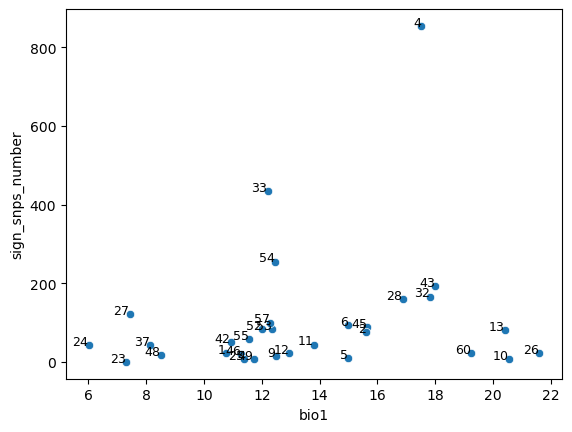

In [164]:
import seaborn as sns
import matplotlib.pyplot as plt

# Your existing scatterplot
sns.scatterplot(data=sign_snps_number, x='bio1', y='sign_snps_number')

# Loop through each point in the data and add the corresponding label
for i in range(sign_snps_number.shape[0]):
    plt.text(
        sign_snps_number['bio1'].iloc[i],        # X-coordinate (bio1)
        sign_snps_number['sign_snps_number'].iloc[i],  # Y-coordinate (sign_snps_number)
        sign_snps_number['site'].iloc[i],        # Label (site)
        fontsize=9,                              # Font size for the labels
        ha='right'                               # Align text to the right
    )

# Show the plot
plt.show()


In [ ]:
parallelism = pd.read_csv('../../key_files/generation_1_parallelism.txt',sep = '\t')

In [166]:
sign_snps_number = sign_snps_number.merge(parallelism, on = 'site')

In [168]:
sign_snps_number[sign_snps_number['source'] == 'snp']

,site,sign_snps_number,bio1,mean,lower,upper,generation,source
0,46,21,11.277027,0.558565,0.543584,0.573762,1,snp
2,55,58,11.564501,0.157314,0.126377,0.186234,1,snp
4,28,159,16.868309,0.104456,0.034784,0.169436,1,snp
6,10,7,20.550923,0.233950,0.174433,0.287781,1,snp
8,6,94,14.989079,0.480042,0.425756,0.538647,1,snp
10,1,23,10.743906,0.399356,0.369797,0.428495,1,snp
12,60,22,19.248051,0.071068,0.036245,0.102571,1,snp
14,25,7,11.393515,0.111906,0.085221,0.138089,1,snp
16,52,83,12.005284,0.176809,0.135817,0.217816,1,snp
18,32,166,17.815169,0.777680,0.762048,0.793780,1,snp


In [188]:
unique_ecotypes = pd.read_csv('../../key_files/unique_ecotypes.csv')

In [191]:
unique_ecotypes_persite = unique_ecotypes.groupby('site')['unique_ecotypes'].mean().reset_index()

In [197]:
shannon_div = pd.read_csv('../../key_files/shannon_div.csv')


In [198]:
shannon_div = shannon_div.groupby('site')['0'].mean().reset_index()

In [200]:
shannon_div.columns = ['site', 'shannon_div']

In [201]:
sign_snps_number = sign_snps_number.merge(shannon_div)

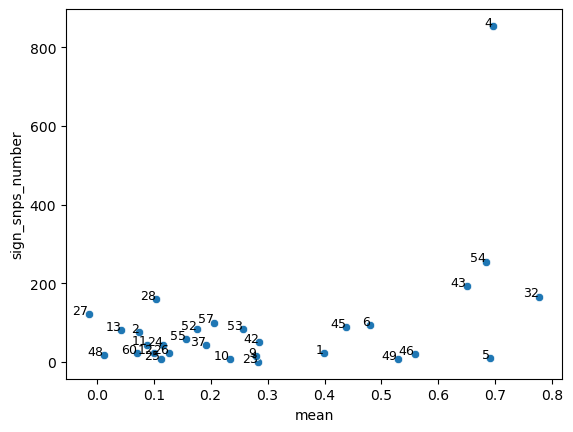

In [173]:
import seaborn as sns
import matplotlib.pyplot as plt
filter = sign_snps_number[sign_snps_number['source'] == 'snp']
# Your existing scatterplot
sns.scatterplot(data=filter, x='mean', y='sign_snps_number')

# Loop through each point in the data and add the corresponding label
for i in range(filter.shape[0]):
    plt.text(
        filter['mean'].iloc[i],        # X-coordinate (bio1)
        filter['sign_snps_number'].iloc[i],  # Y-coordinate (sign_snps_number)
        filter['site'].iloc[i],        # Label (site)
        fontsize=9,                              # Font size for the labels
        ha='right'                               # Align text to the right
    )

# Show the plot
plt.show()


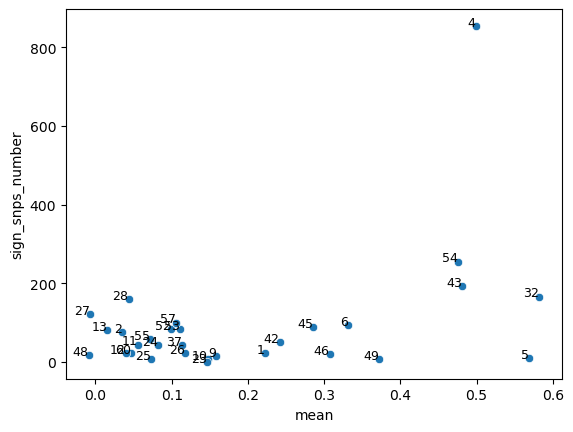

In [174]:
import seaborn as sns
import matplotlib.pyplot as plt
filter = sign_snps_number[sign_snps_number['source'] == 'ecotype']
# Your existing scatterplot
sns.scatterplot(data=filter, x='mean', y='sign_snps_number')

# Loop through each point in the data and add the corresponding label
for i in range(filter.shape[0]):
    plt.text(
        filter['mean'].iloc[i],        # X-coordinate (bio1)
        filter['sign_snps_number'].iloc[i],  # Y-coordinate (sign_snps_number)
        filter['site'].iloc[i],        # Label (site)
        fontsize=9,                              # Font size for the labels
        ha='right'                               # Align text to the right
    )

# Show the plot
plt.show()


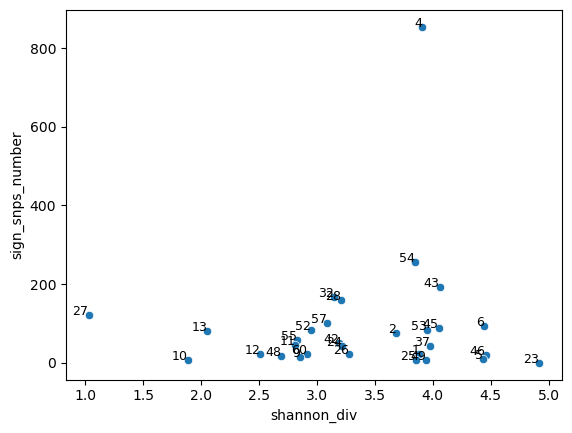

In [204]:
import seaborn as sns
import matplotlib.pyplot as plt
filter = sign_snps_number[sign_snps_number['source'] == 'snp']
# Your existing scatterplot
sns.scatterplot(data=filter, x='shannon_div', y='sign_snps_number')

# Loop through each point in the data and add the corresponding label
for i in range(filter.shape[0]):
    plt.text(
        filter['shannon_div'].iloc[i],        # X-coordinate (bio1)
        filter['sign_snps_number'].iloc[i],  # Y-coordinate (sign_snps_number)
        filter['site'].iloc[i],        # Label (site)
        fontsize=9,                              # Font size for the labels
        ha='right'                               # Align text to the right
    )

# Show the plot
plt.show()

In [175]:
from itertools import combinations

# Find all pairwise combinations of sites
pairwise_intersections = {}
for (site1, site2) in combinations(sign_snps_names_dict.keys(), 2):
    # Convert lists to sets and find the intersection
    intersection = set(sign_snps_names_dict[site1]).intersection(set(sign_snps_names_dict[site2]))
    
    # Store the result in a dictionary with the pair of sites as the key
    pairwise_intersections[(site1, site2)] = intersection

In [176]:
filtered_intersections = {pair: blocks for pair, blocks in pairwise_intersections.items() if blocks}

In [177]:
climate = pd.read_csv('../../key_files/bioclimvars_experimental_sites_era5.csv')[['site', 'bio1']]

climatic_distances = []
for (site1, site2) in combinations(climate['site'], 2):
    bio1_site1 = climate.loc[climate['site'] == site1, 'bio1'].values[0]
    bio1_site2 = climate.loc[climate['site'] == site2, 'bio1'].values[0]
    distance = (bio1_site1 - bio1_site2) ** 2
    climatic_distances.append({'site_pair': (site1, site2), 'climatic_distance': distance})


climatic_distances_df = pd.DataFrame(climatic_distances)


# Add a column for number of shared SNPs to the climatic_distances_df
climatic_distances_df['shared_snps'] = climatic_distances_df['site_pair'].apply(
    lambda pair: len(filtered_intersections.get(pair, []))
)

# Add a column for number of shared SNPs to the climatic_distances_df
climatic_distances_df['shared_snps_names'] = climatic_distances_df['site_pair'].apply(
    lambda pair: filtered_intersections.get(pair, [])
)
# Step 3: Calculate the correlation between climatic distance and shared SNPs
#correlation = climatic_distances_df['climatic_distance'].corr(climatic_distances_df['shared_snps'])

In [180]:
climatic_distances_df[climatic_distances_df['shared_snps']!=0]

,site_pair,climatic_distance,shared_snps,shared_snps_names
16,"(1, 32)",50.002763,2,"{1_5086645, 1_5086459}"
20,"(1, 4)",45.827061,2,"{5_4289113, 5_4288893}"
34,"(1, 54)",2.877309,5,"{5_6182499, 5_6179031, 5_6177847, 5_6175237, 5..."
257,"(2, 4)",3.681977,1,{5_4283251}
458,"(26, 4)",16.727130,2,"{2_6178048, 5_3592628}"
598,"(32, 4)",0.091020,5,"{4_12917912, 4_12922135, 4_12922156, 4_1291788..."
600,"(32, 42)",47.446177,1,{1_2929138}
601,"(32, 43)",0.034515,9,"{2_12310605, 4_12917912, 1_5104881, 4_8953306,..."
602,"(32, 45)",4.669413,3,"{1_5104881, 1_5091879, 1_5105013}"
607,"(32, 5)",7.945710,1,{3_415092}


In [115]:
from itertools import combinations

# Find all pairwise combinations of sites
pairwise_intersections_blocks = {}
for (site1, site2) in combinations(sign_blocks_names_dict.keys(), 2):
    # Convert lists to sets and find the intersection
    intersection = set(sign_blocks_names_dict[site1]).intersection(set(sign_blocks_names_dict[site2]))
    
    # Store the result in a dictionary with the pair of sites as the key
    pairwise_intersections_blocks[(site1, site2)] = intersection

In [116]:
filtered_intersections_blocks = {pair: blocks for pair, blocks in pairwise_intersections_blocks.items() if blocks}

In [117]:
climate = pd.read_csv('../../key_files/bioclimvars_experimental_sites_era5.csv')[['site', 'bio1']]

climatic_distances = []
for (site1, site2) in combinations(climate['site'], 2):
    bio1_site1 = climate.loc[climate['site'] == site1, 'bio1'].values[0]
    bio1_site2 = climate.loc[climate['site'] == site2, 'bio1'].values[0]
    distance = (bio1_site1 - bio1_site2) ** 2
    climatic_distances.append({'site_pair': (site1, site2), 'climatic_distance': distance})


climatic_distances_df_blocks = pd.DataFrame(climatic_distances)


# Add a column for number of shared SNPs to the climatic_distances_df
climatic_distances_df_blocks['shared_blocks'] = climatic_distances_df_blocks['site_pair'].apply(
    lambda pair: len(filtered_intersections_blocks.get(pair, []))
)

# Add a column for number of shared SNPs to the climatic_distances_df
climatic_distances_df_blocks['shared_blocks_names'] = climatic_distances_df_blocks['site_pair'].apply(
    lambda pair: filtered_intersections_blocks.get(pair, [])
)
# Step 3: Calculate the correlation between climatic distance and shared SNPs
#correlation = climatic_distances_df['climatic_distance'].corr(climatic_distances_df['shared_snps'])

<Axes: xlabel='climatic_distance', ylabel='shared_blocks'>

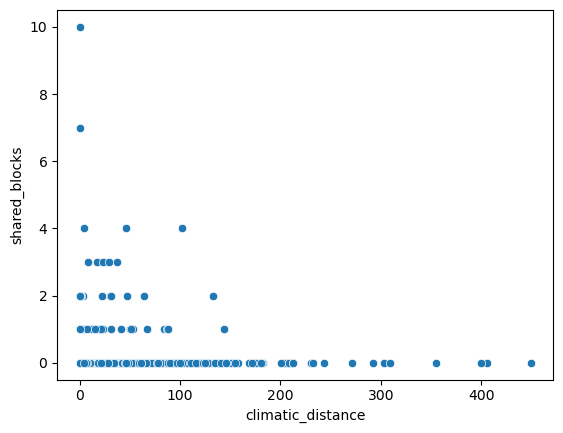

In [121]:
sns.scatterplot(climatic_distances_df_blocks, x = 'climatic_distance', y='shared_blocks')

In [124]:
climatic_distances_df_blocks.sort_values('shared_blocks',ascending=False).head(10)

,site_pair,climatic_distance,shared_blocks,shared_blocks_names
598,"(32, 4)",0.091020,10,"{1_590, 5_3028, 5_953, 2_930, 1_2407, 5_396, 3..."
601,"(32, 43)",0.034515,7,"{1_590, 4_1406, 2_945, 3_328, 2_1315, 2_1314, ..."
602,"(32, 45)",4.669413,4,"{2_930, 1_590, 1_3260, 5_403}"
20,"(1, 4)",45.827061,4,"{1_590, 4_2740, 3_3151, 5_414}"
488,"(27, 4)",101.774390,4,"{5_3028, 2_1915, 1_1079, 3_2708}"
612,"(32, 54)",28.890625,3,"{3_328, 3_502, 1_590}"
24,"(1, 45)",24.111838,3,"{1_590, 2_1967, 5_549}"
458,"(26, 4)",16.727130,3,"{5_396, 2_680, 5_953}"
427,"(25, 4)",37.453902,3,"{1_2407, 1_2853, 3_338}"
505,"(27, 57)",23.535461,3,"{3_2702, 3_589, 1_3923}"


In [127]:
# Flatten the list of shared blocks and count their occurrences
block_count = {}

for blocks in climatic_distances_df_blocks['shared_blocks_names']:
    for block in blocks:
        if block in block_count:
            block_count[block] += 1
        else:
            block_count[block] = 1

# Convert the count dictionary into a dataframe and sort by most frequent blocks
block_count_df = pd.DataFrame(list(block_count.items()), columns=['block', 'count']).sort_values(by='count', ascending=False)


In [128]:
block_count_df

,block,count,site_pairs
0,1_590,10,"[(1, 32), (1, 4), (1, 43), (1, 45), (1, 54), (..."
1,1_2407,5,"[(25, 32), (25, 33), (25, 4), (32, 33), (32, 4)]"
2,4_2584,4,"[(2, 4), (2, 43), (32, 4), (32, 43)]"
3,3_1381,3,"[(52, 53), (52, 57), (53, 57)]"
4,3_31,3,"[(32, 5), (32, 53), (5, 53)]"
...,...,...,...
66,2_1874,1,"[(28, 4)]"
67,2_692,1,"[(12, 33)]"
68,2_529,1,"[(28, 54)]"
69,3_554,1,"[(28, 57)]"


In [120]:
climatic_distances_df_blocks[climatic_distances_df_blocks['shared_blocks']!=0]

,site_pair,climatic_distance,shared_blocks,shared_blocks_names
5,"(1, 2)",23.529494,1,{5_414}
16,"(1, 32)",50.002763,1,{1_590}
17,"(1, 33)",2.116435,1,{4_2740}
19,"(1, 37)",6.832440,1,{5_549}
20,"(1, 4)",45.827061,4,"{1_590, 4_2740, 3_3151, 5_414}"
...,...,...,...,...
891,"(52, 53)",0.127401,2,"{3_1381, 4_814}"
892,"(52, 54)",0.189125,2,"{5_542, 3_3090}"
895,"(52, 57)",0.073548,2,"{1_4736, 3_1381}"
904,"(53, 57)",0.007351,1,{3_1381}


In [113]:
climatic_distances_df[climatic_distances_df['shared_snps']!=0]

,site_pair,climatic_distance,shared_snps,shared_snps_names
16,"(1, 32)",50.002763,2,"{1_5086645, 1_5086459}"
20,"(1, 4)",45.827061,2,"{5_4289113, 5_4288893}"
34,"(1, 54)",2.877309,5,"{5_6182499, 5_6179031, 5_6177847, 5_6175237, 5..."
257,"(2, 4)",3.681977,1,{5_4283251}
458,"(26, 4)",16.727130,2,"{2_6178048, 5_3592628}"
598,"(32, 4)",0.091020,5,"{4_12917912, 4_12922135, 4_12922156, 4_1291788..."
600,"(32, 42)",47.446177,1,{1_2929138}
601,"(32, 43)",0.034515,9,"{2_12310605, 4_12917912, 1_5104881, 4_8953306,..."
602,"(32, 45)",4.669413,3,"{1_5104881, 1_5091879, 1_5105013}"
607,"(32, 5)",7.945710,1,{3_415092}


In [69]:
filtered_intersections = {pair: blocks for pair, blocks in pairwise_intersections.items() if blocks}